Data Dictionary

Booking_ID: unique identifier of each booking \

no_of_adults: Number of adults

no_of_children: Number of Children

no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

type_of_meal_plan: Type of meal plan booked by the customer:

required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)

room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.

lead_time: Number of days between the date of booking and the arrival date

arrival_year: Year of arrival date

arrival_month: Month of arrival date

arrival_date: Date of the month

market_segment_type: Market segment designation.

repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)

no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking

no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking

avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)

no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)

booking_status: Flag indicating if the booking was canceled or not. --- RESPONSE


Description

Can you predict if the customer is going to honor the reservation or cancel it?

Data exploration – inspect data types, missing values, descriptive statistics, and visualize distributions and relationships with the target variable

Predictor definition – assess predictor strength (correlation, mutual information, univariate importance) and select a compact, justified subset

Variable encoding – encode categorical variables (ordinal, one-hot, or target encoding) and apply numerical transformations where appropriate

Hyperparameter selection – justify your hyperparameter selection (manual trials, expert settings, hyperparameter optimization)

Model score validation – evaluate on the test dataset using proper metrics

SHAP value interpretation – compute SHAP values, produce a summary plot, and explain the influence of top predictors on booking_status


Evaluation
Metric The evaluation metric for this competition is AUC (area under the curve).
The AUC score, commonly used in credit risk tasks, measures performance of models for prediction of binary targets. You shall use sklearn package to evaluate the metric on your train dataset. See https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

Submission Format
Submission csv should contain two columns:

Booking_ID - column ID for the observation
prediction - column consisting of the predicted value Submission was tested using comma separated csv format.

 ## Data exploration
 – inspect data types, missing values, descriptive statistics, and visualize distributions and relationships with the target variable

In [2]:
import pandas as pd
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from random import sample
import shap
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from pathlib import Path
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score





In [3]:
# set width of Jupyter notebook
from IPython.core.display import HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

# set some visual properties of displaying pandas DataFrame
pd.options.display.max_columns=200
pd.options.display.max_rows=200

In [4]:
# Load data - set index column, decimal point, separator
data_train_path = Path("Data/2025_DS2_HW1_data_train.csv")
data_train = pd.read_csv(data_train_path, sep = ',', decimal = '.', index_col = 'Booking_ID')

In [5]:
data_train.head(
)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
Booking_ID,,,,,,,,,,,,,,,,,,
INN10204,NaN,NaN,NaN,2.0,Meal Plan 2,NaN,Room_Type 6,NaN,2018.0,9.0,NaN,Online,0.0,0.0,NaN,NaN,1.0,0.0
INN20020,NaN,NaN,NaN,2.0,Meal Plan 1,NaN,NaN,NaN,NaN,12.0,NaN,Online,0.0,0.0,0.0,NaN,NaN,0.0
INN16435,1.0,NaN,NaN,2.0,NaN,0.0,Room_Type 1,NaN,2018.0,11.0,NaN,NaN,0.0,0.0,NaN,NaN,1.0,0.0
INN07143,3.0,NaN,NaN,3.0,NaN,NaN,NaN,100.0,2018.0,5.0,NaN,Online,0.0,0.0,NaN,NaN,2.0,0.0
INN20511,1.0,0.0,1.0,1.0,Meal Plan 1,0.0,NaN,NaN,2018.0,11.0,NaN,NaN,0.0,0.0,0.0,150.0,NaN,1.0


In [5]:
# Print some numbers about data sample size
print(f'Number of rows:   {data_train.shape[0]:,}'.replace(',', ' '))
print(f'Number of unique indexes:   {data_train.index.nunique():,}'.replace(',', ' '))
print(f'Number of columns:   {data_train.shape[1]:,}'.replace(',', ' '))

Number of rows:   32 647
Number of unique indexes:   32 647
Number of columns:   18


In [6]:
# We check the format of the data
data_train.dtypes

no_of_adults                            float64
no_of_children                          float64
no_of_weekend_nights                    float64
no_of_week_nights                       float64
type_of_meal_plan                        object
required_car_parking_space              float64
room_type_reserved                       object
lead_time                               float64
arrival_year                            float64
arrival_month                           float64
arrival_date                            float64
market_segment_type                      object
repeated_guest                          float64
no_of_previous_cancellations            float64
no_of_previous_bookings_not_canceled    float64
avg_price_per_room                      float64
no_of_special_requests                  float64
booking_status                          float64
dtype: object

In [7]:
# Number of missing values in each column
data_train.isna().sum()

no_of_adults                             4416
no_of_children                          27604
no_of_weekend_nights                    24918
no_of_week_nights                        8360
type_of_meal_plan                       16103
required_car_parking_space              14784
room_type_reserved                      21287
lead_time                               25712
arrival_year                             2993
arrival_month                             907
arrival_date                            27190
market_segment_type                     14121
repeated_guest                          24978
no_of_previous_cancellations               69
no_of_previous_bookings_not_canceled    14621
avg_price_per_room                      23589
no_of_special_requests                   7450
booking_status                            352
dtype: int64

Worse situation in terms of NAs is for predictors lead_time, no_of_children,arrival_date,avg_price_per_room, no_of_week_nights. However, we will have to be careful about removing them as we do not have too many columns available and they might contain in the few available observations useful information.

In [8]:
data_train.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,28231.000000,5043.000000,7729.000000,24287.000000,17863.000000,6935.000000,29654.000000,31740.000000,5457.000000,7669.000000,32578.000000,18026.000000,9058.000000,25197.000000,32295.000000
mean,1.845312,0.103510,0.807737,2.204966,0.033645,86.213266,2017.820092,7.419817,15.523731,0.026209,0.023543,0.162155,103.601652,0.622257,0.325778
std,0.516860,0.407673,0.873931,1.411324,0.180319,85.926525,0.384118,3.062828,8.726069,0.159768,0.369300,1.790668,35.382301,0.784652,0.468672
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,18.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.750000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,59.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,127.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,121.000000,1.000000,1.000000
max,4.000000,9.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000,1.000000


In [17]:
#rename for simplicity
data = data_train.copy()

In [19]:
# Drop rows where the target variable is missing - supervised learning
data = data.dropna(subset=['booking_status'])

# Rename columns for easier typing
rename_dict = {
    'no_of_adults': 'adults',
    'no_of_children': 'children',
    'no_of_weekend_nights': 'weekend_nights',
    'no_of_week_nights': 'week_nights',
    'type_of_meal_plan': 'meal_plan',
    'required_car_parking_space': 'parking_space',
    'room_type_reserved': 'room_type',
    'market_segment_type': 'market_segment',
    'repeated_guest': 'repeated_guest',
    'no_of_previous_cancellations': 'prev_cancellations',
    'no_of_previous_bookings_not_canceled': 'prev_not_canceled',
    'avg_price_per_room': 'avg_price',
    'no_of_special_requests': 'special_requests'
}
data = data.rename(columns=rename_dict)

print(f"Data shape after cleaning targets: {data.shape}")

#352 without target dropped - not too much information lost

Data shape after cleaning targets: (32295, 18)


In [20]:
#Define the target variable
target = 'booking_status'
features = data.drop(columns=[target])

#automated split based on memory types
num_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = features.select_dtypes(include=['object', 'category']).columns.tolist()



In [12]:
data.dtypes

adults                float64
children              float64
weekend_nights        float64
week_nights           float64
meal_plan              object
parking_space         float64
room_type              object
lead_time             float64
arrival_year          float64
arrival_month         float64
arrival_date          float64
market_segment         object
repeated_guest        float64
prev_cancellations    float64
prev_not_canceled     float64
avg_price             float64
special_requests      float64
booking_status        float64
dtype: object

## Features Engineering

In [21]:
# We try to create specific datetime column for the date, but we have many NAs for day, month, year so that the final column does not contain almost any information - we will drop it later

# Convert to float, fill NaNs, convert to int (drops .0), then to string
year_str = pd.to_numeric(data['arrival_year'], errors='coerce').fillna(-1).astype(int).astype(str)
month_str = pd.to_numeric(data['arrival_month'], errors='coerce').fillna(-1).astype(int).astype(str)
day_str = pd.to_numeric(data['arrival_date'], errors='coerce').fillna(-1).astype(int).astype(str)

# Combine and convert to datetime
data['arrival_date_full'] = pd.to_datetime(
    year_str + '-' + month_str + '-' + day_str,
    format='%Y-%m-%d',
    errors='coerce'
)

# Extract the day of the week
data['arrival_day_of_week'] = data['arrival_date_full'].dt.dayofweek

# --- Historical Cancellation Rate ---
data['total_prev_bookings'] = data['prev_cancellations'] + data['prev_not_canceled']

# Calculate the rate. If they have no history, then NA
#data['prev_cancel_rate'] = (data['prev_cancellations'] / data['total_prev_bookings']).replace([np.inf, -np.inf], np.nan)

# --- Guest & Stay
# Total guests in the room - again, seems like nice idea but because many NAs we created even more, so this column will be later dropped
data['total_guests'] = data['adults'] + data['children']

# Total length of stay
data['total_stay'] = data['weekend_nights'] + data['week_nights']

#manually setting some variables to be categorical as they logically are
imposters = [
    'parking_space',
    'repeated_guest',
    'arrival_year',
    'arrival_month',
    'arrival_date',
    'arrival_day_of_week'
]

# Move the imposters from the numerical list to the categorical list
for col in imposters:
    if col in num_cols:
        num_cols.remove(col)
        cat_cols.append(col)

# convert to proper Pandas 'category' dtype
for col in imposters:
    data[col] = data[col].astype('category')

print("New columns added:")
print(['arrival_date_full', 'arrival_day_of_week', 'total_prev_bookings', 'prev_cancel_rate', 'total_guests', 'total_stay'])

New columns added:
['arrival_date_full', 'arrival_day_of_week', 'total_prev_bookings', 'prev_cancel_rate', 'total_guests', 'total_stay']


In [11]:
data.columns
len(data.columns)
#here also histograms

24

In [14]:
data.dtypes

adults                        float64
children                      float64
weekend_nights                float64
week_nights                   float64
meal_plan                      object
parking_space                category
room_type                      object
lead_time                     float64
arrival_year                 category
arrival_month                category
arrival_date                 category
market_segment                 object
repeated_guest               category
prev_cancellations            float64
prev_not_canceled             float64
avg_price                     float64
special_requests              float64
booking_status                float64
arrival_date_full      datetime64[ns]
arrival_day_of_week          category
total_prev_bookings           float64
prev_cancel_rate              float64
total_guests                  float64
total_stay                    float64
dtype: object

## Plots and observations

- twice as much non-canceled as canceled - data is not completely balanced but we have enough observations from both categories
- lot more NA for non-cancled than canceled (about twice as much) - but also more available data in general
- most cancellations in october

- lead_time: Guests who book close to their arrival date almost never cancel. As the lead time extends past 100 days, the probability of cancellation high. The correlation matrix shows this is strongest continuous numerical predictor (0.43).

- special_requests: Guests with 0 special requests have a high cancellation rate (nearly 40-50%).the moment a guest makes 1, 2, or 3 special requests, the cancellation rate drops.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warnin

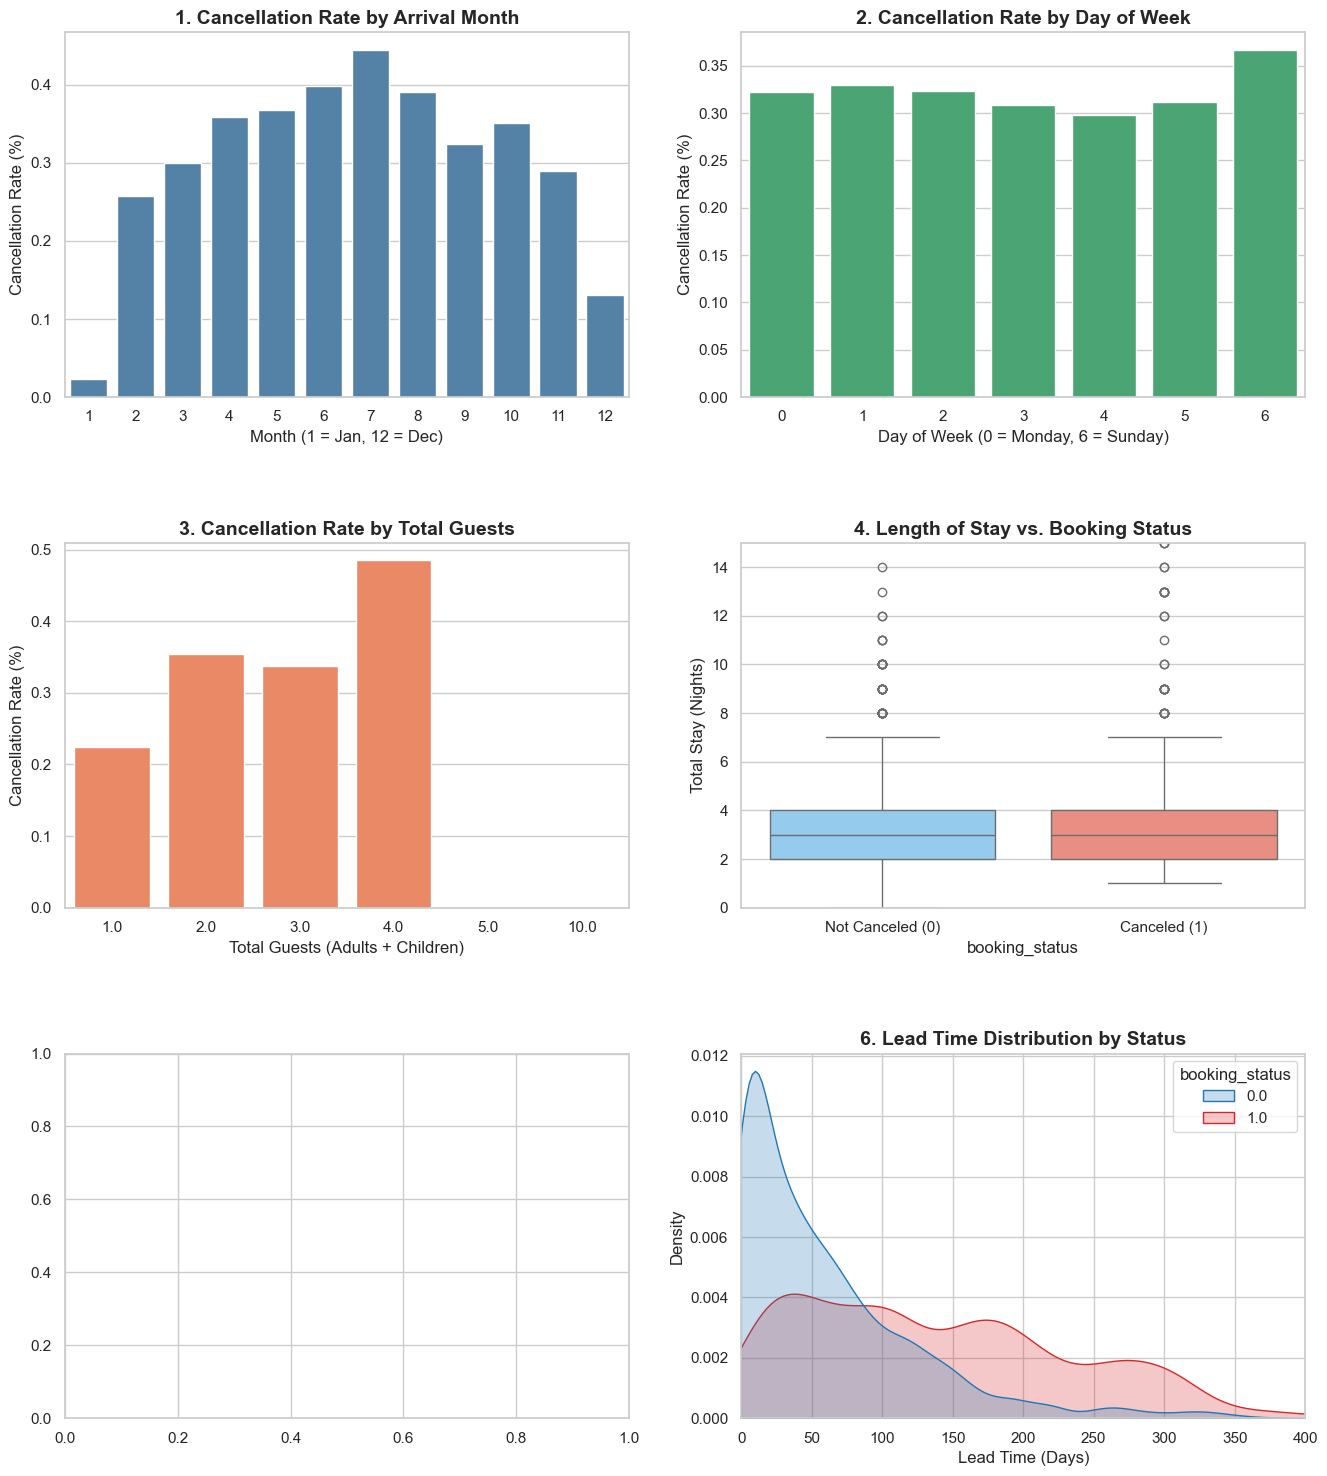

In [23]:
#to display months correctly
date_cols = ['arrival_year', 'arrival_month', 'arrival_date', 'arrival_day_of_week']
for col in date_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce').astype('Int64')

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# --- Plot 1: Seasonality (Cancellation Rate by Month) ---
sns.barplot(
    data=data,
    x='arrival_month',
    y='booking_status',
    ax=axes[0, 0],
    errorbar=None,
    color='steelblue'
)
axes[0, 0].set_title('1. Cancellation Rate by Arrival Month', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Cancellation Rate (%)')
axes[0, 0].set_xlabel('Month (1 = Jan, 12 = Dec)')

# --- Plot 2: Day of Week Trend ---
sns.barplot(
    data=data,
    x='arrival_day_of_week',
    y='booking_status',
    ax=axes[0, 1],
    errorbar=None,
    color='mediumseagreen'
)
axes[0, 1].set_title('2. Cancellation Rate by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Cancellation Rate (%)')
axes[0, 1].set_xlabel('Day of Week (0 = Monday, 6 = Sunday)')

# --- Plot 3: The Engineered "Total Guests" Column ---
sns.barplot(
    data=data,
    x='total_guests',
    y='booking_status',
    ax=axes[1, 0],
    errorbar=None,
    color='coral'
)
axes[1, 0].set_title('3. Cancellation Rate by Total Guests', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Cancellation Rate (%)')
axes[1, 0].set_xlabel('Total Guests (Adults + Children)')

# --- Plot 4: The Engineered "Total Stay" Column (Boxplot) ---
sns.boxplot(
    data=data,
    x='booking_status',
    y='total_stay',
    ax=axes[1, 1],
    palette=['#87CEFA', '#FA8072']
)
axes[1, 1].set_title('4. Length of Stay vs. Booking Status', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])
axes[1, 1].set_ylabel('Total Stay (Nights)')
axes[1, 1].set_ylim(0, 15)

# --- Plot 5: FIXED Violin Plot ---
# Filter out first-time guests just for this visualization
returning_guests = data[data['total_prev_bookings'] > 0]

'''sns.violinplot(
    data=returning_guests,
    x='booking_status',
    y='prev_cancel_rate',
    ax=axes[2, 0],
    palette=['#87CEFA', '#FA8072'],
    inner="quartile",
    cut=0
)
axes[2, 0].set_title('5. Historical Cancel Rate (Returning Guests)', fontsize=14, fontweight='bold')
axes[2, 0].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])
axes[2, 0].set_ylabel('Historical Cancellation Rate (0.0 to 1.0)')'''

# --- Plot 6: Lead Time vs Status ---
sns.kdeplot(
    data=data,
    x='lead_time',
    hue='booking_status',
    ax=axes[2, 1],
    fill=True,
    common_norm=False,
    palette=['#1f77b4', '#d62728']
)
axes[2, 1].set_title('6. Lead Time Distribution by Status', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Lead Time (Days)')
axes[2, 1].set_xlim(0, 400)

plt.show()

From these plots we observe that Lead Time will probably be a strong predictor as the empirical distribution differs quite a lot, number of guests might also tell us something, and there also seems to be difference for months but not so much for the days of the week.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future

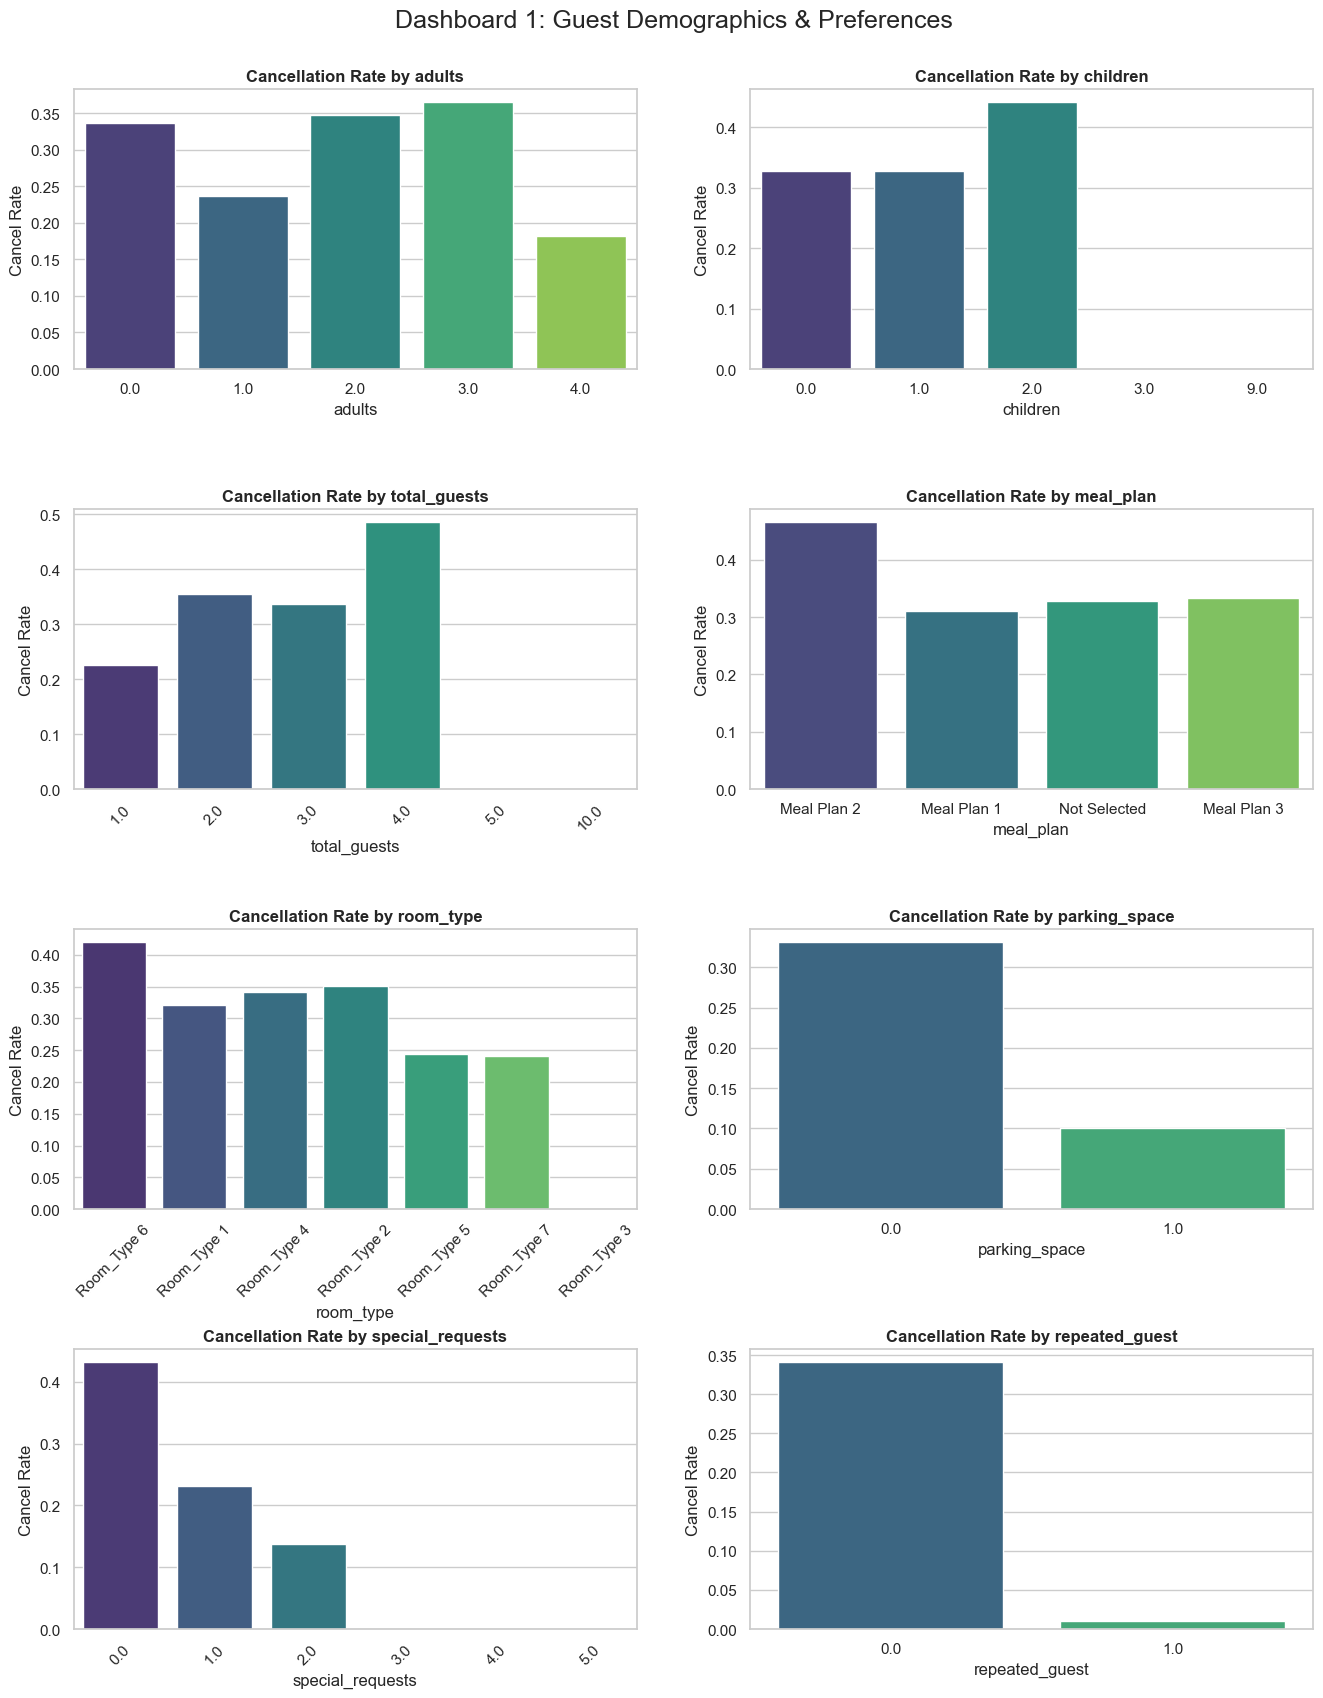

In [16]:
sns.set_theme(style="whitegrid", palette="muted")

# 1. Demographics & Room Details (8 columns)
cat_cols_1 = ['adults', 'children', 'total_guests', 'meal_plan',
              'room_type', 'parking_space', 'special_requests', 'repeated_guest']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.2)
axes = axes.flatten()

for i, col in enumerate(cat_cols_1):
    sns.barplot(data=data, x=col, y='booking_status', ax=axes[i], errorbar=None, palette='viridis')
    axes[i].set_title(f'Cancellation Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cancel Rate')

    # Rotate x-labels if there are too many categories (like room_type)
    if data[col].nunique() > 5:
        axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Dashboard 1: Guest Demographics & Preferences", fontsize=18, y=0.92)
plt.show()

From these plots, the predictor special_requests, repeated guest, parking_space, room_type and maybe total_guest seem to help us the most with predicitng cancellation



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pa

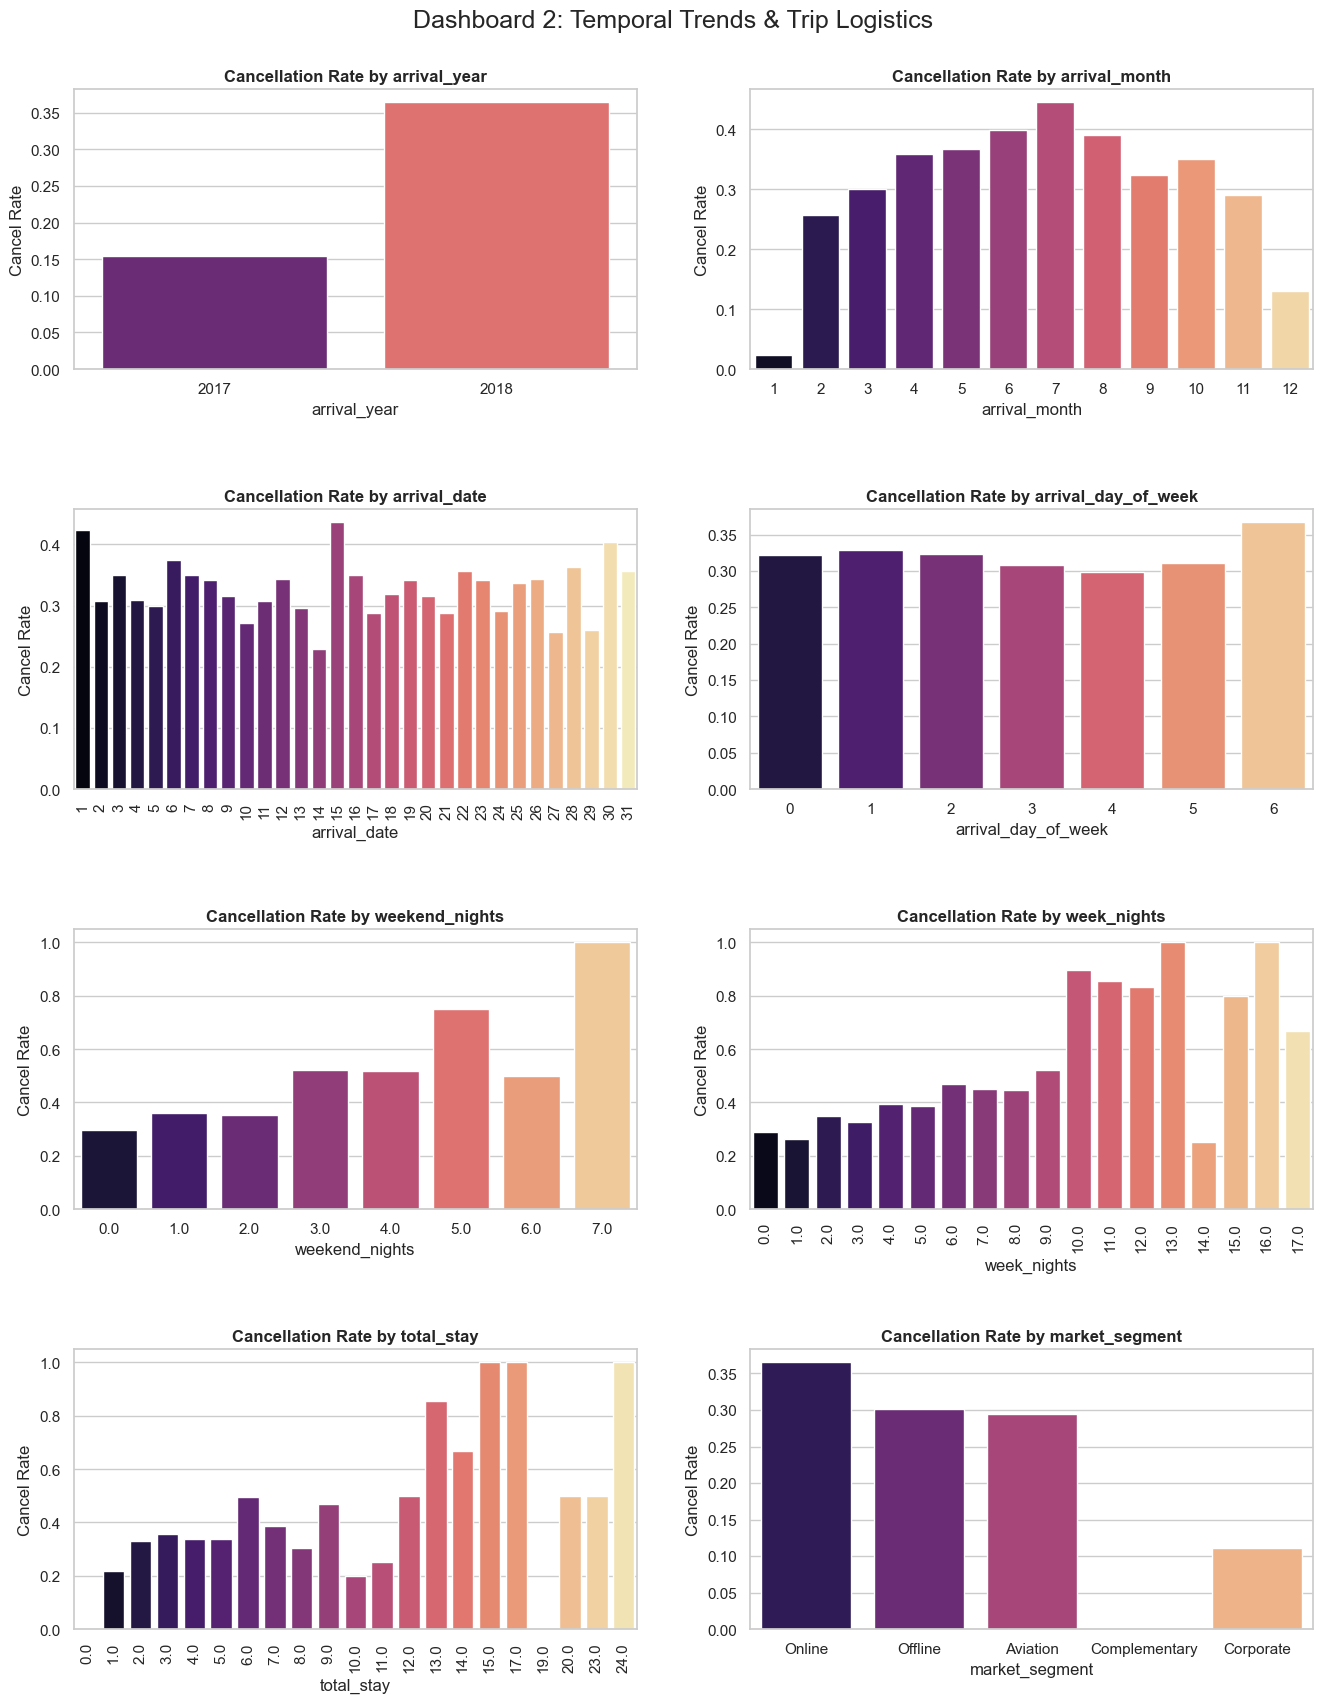

In [24]:
# Time, Dates & Stay Length (8 columns)
cat_cols_2 = ['arrival_year', 'arrival_month', 'arrival_date', 'arrival_day_of_week',
              'weekend_nights', 'week_nights', 'total_stay', 'market_segment']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.2)
axes = axes.flatten()

for i, col in enumerate(cat_cols_2):
    sns.barplot(data=data, x=col, y='booking_status', ax=axes[i], errorbar=None, palette='magma')
    axes[i].set_title(f'Cancellation Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cancel Rate')


    if col in ['arrival_date', 'total_stay', 'week_nights'] and data[col].nunique() > 10:
        axes[i].tick_params(axis='x', rotation=90)


plt.suptitle("Dashboard 2: Temporal Trends & Trip Logistics", fontsize=18, y=0.92)
plt.show()

From these graphs the strongest predictors seem to be total_stay (or day of week/weekend, we will choose from those as there is multicollinearity), arrival month and year.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_gro

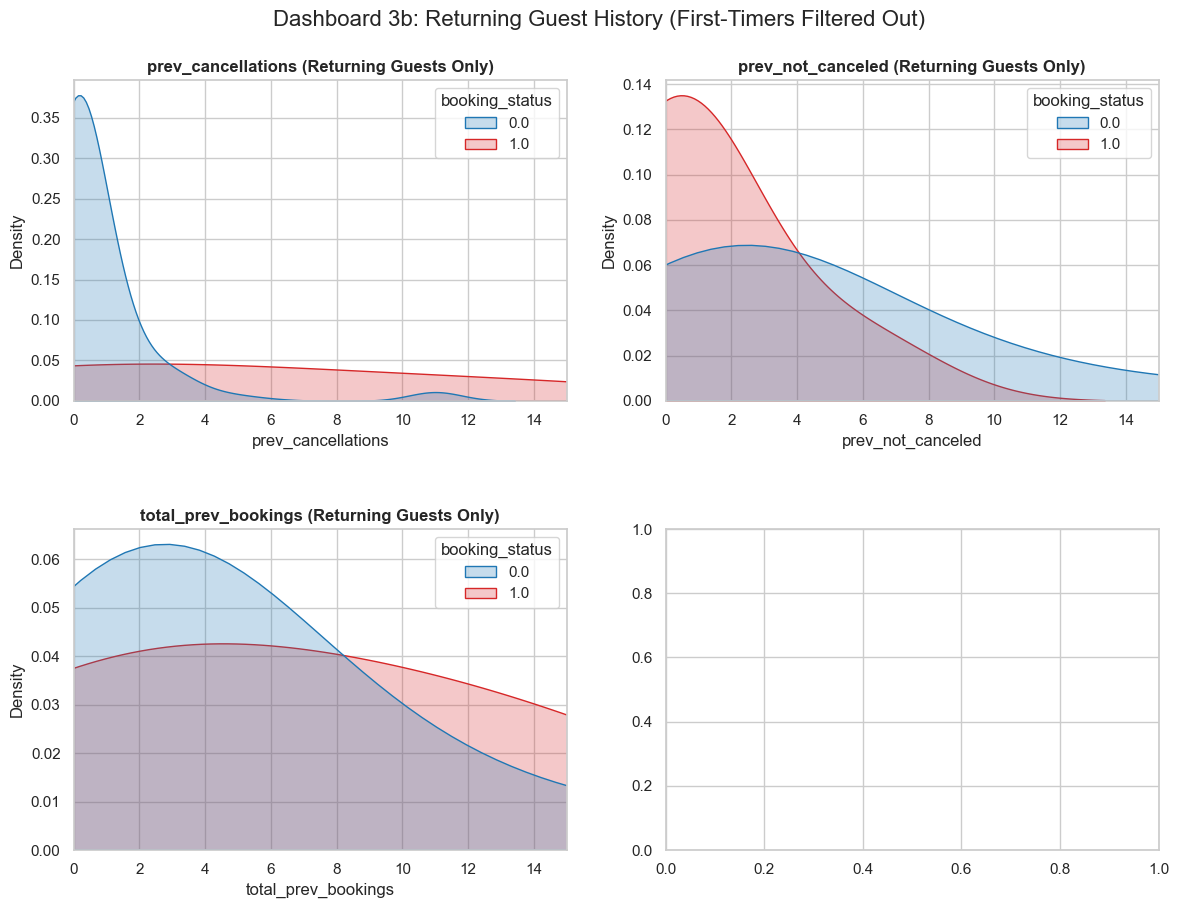

In [26]:
# --- The Fix for Dashboard 3: History Plots ---
sns.set_theme(style="whitegrid", palette="muted")

history_cols = ['prev_cancellations', 'prev_not_canceled', 'total_prev_bookings']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
axes = axes.flatten()

#  Filter out the first-time guests (the zeroes) just for these plots for better visibility, as most of the people from the dataset are not returning guests so there would be just tiny invisible spike
returning_guests = data[data['total_prev_bookings'] > 0]

for i, col in enumerate(history_cols):
    sns.kdeplot(
        data=returning_guests,
        x=col,
        hue='booking_status',
        ax=axes[i],
        fill=True,
        common_norm=False,
        palette=['#1f77b4', '#d62728'],
        bw_adjust=1.5 # Smoothes out the curves a bit
    )
    axes[i].set_title(f'{col} (Returning Guests Only)', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density')

    # Cap the x-axis so we don't get stretched by one crazy guest with 50 previous stays
    if col != 'prev_cancel_rate':
        axes[i].set_xlim(0, 15)

plt.suptitle("Dashboard 3b: Returning Guest History (First-Timers Filtered Out)", fontsize=16, y=0.95)
plt.show()

Here we observe the distribution for returning guests, for them it seems that previous cancel rate can tell us something which holds similar information as prev cancellations (makes sense as it is a transformation of that)

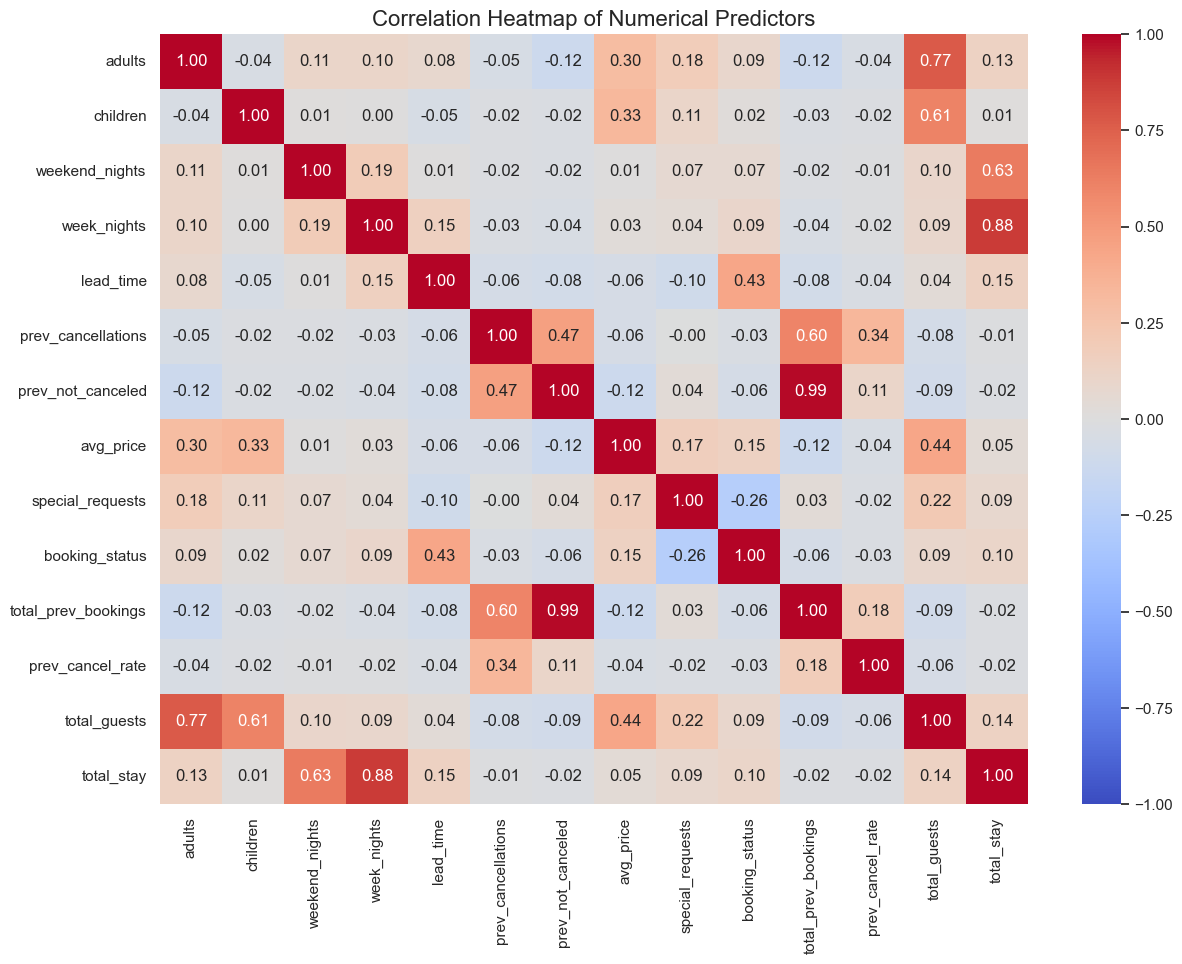

In [19]:
### --- Heatmap ---

sns.set_theme(style="whitegrid")

# Select only numerical columns for correlation
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = data[num_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Predictors", fontsize=16)
plt.show()

Problems:
- week_nights and total_stay are correlated at 0.88.

- adults and total_guests are correlated at 0.77.

- prev_not_canceled and total_prev_bookings are correlated at 0.99.

Leaving perfectly correlated variables in the dataset is generally a bad idea, as it messes feature importance and can cause instability in some models. - we will choose just some of those to get rid of possible problems with multicollinearity

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.


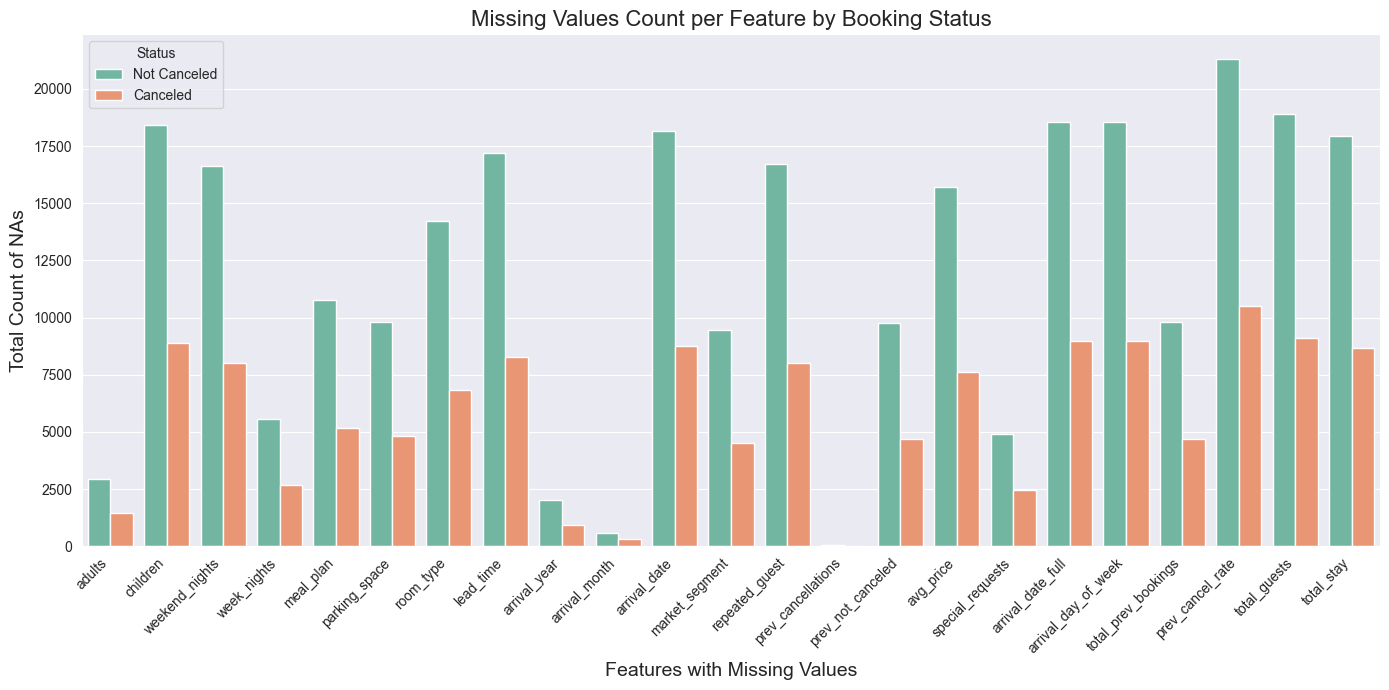

In [12]:
### ---- NA plot

missing_mask = data.isnull()

# add the target variable to this mask so we can group by it
missing_mask['booking_status'] = data['booking_status']

# Group by the target and sum the missing values
missing_grouped = missing_mask.groupby('booking_status').sum().T

missing_grouped = missing_grouped.drop('booking_status', errors='ignore')

# Keep features that actually have at least 1 missing value across the whole dataset
missing_grouped = missing_grouped[missing_grouped.sum(axis=1) > 0]

#
if not missing_grouped.empty:
    missing_grouped = missing_grouped.reset_index().rename(columns={'index': 'Feature'})
    missing_grouped.columns = ['Feature', 'Not Canceled', 'Canceled']
    missing_melted = missing_grouped.melt(id_vars='Feature', var_name='Status', value_name='Missing Count')

    plt.figure(figsize=(14, 7))
    sns.barplot(data=missing_melted, x='Feature', y='Missing Count', hue='Status', palette='Set2')

    plt.title('Missing Values Count per Feature by Booking Status', fontsize=16)
    plt.xlabel('Features with Missing Values', fontsize=14)
    plt.ylabel('Total Count of NAs', fontsize=14)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset to plot!")

For some columns (as mentioned above) there are a lot of NAs, the proportions seem to generally correspond with proportion of the response (2:1 noncancelled:canceled)

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.


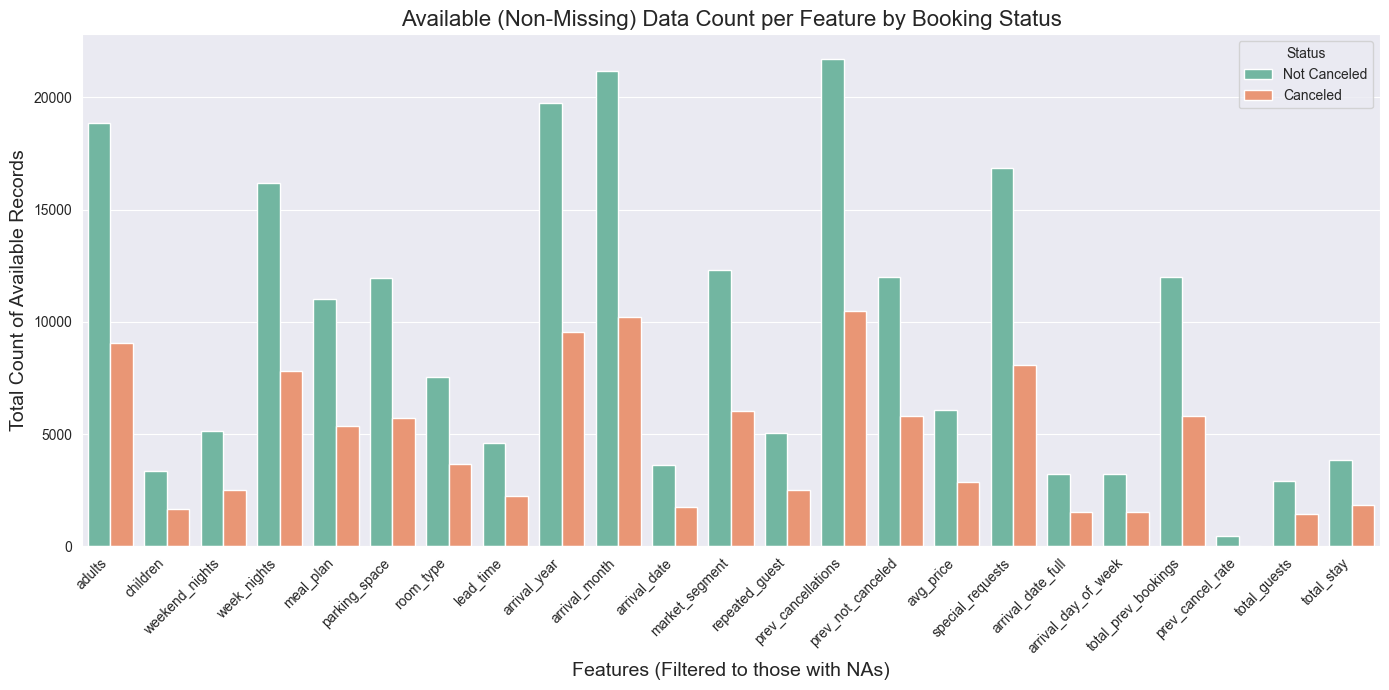

In [13]:
### ---- Non NA counts ----
available_mask = data.notnull()

available_mask['booking_status'] = data['booking_status']

# Group by target and sum the available values
available_grouped = available_mask.groupby('booking_status').sum().T
available_grouped = available_grouped.drop('booking_status', errors='ignore')

# Filter to show ONLY the features that actually had missing values
columns_with_nans = data.columns[data.isnull().sum() > 0]

if len(columns_with_nans) > 0:
    available_grouped = available_grouped.loc[columns_with_nans]

    available_grouped = available_grouped.reset_index().rename(columns={'index': 'Feature'})
    available_grouped.columns = ['Feature', 'Not Canceled', 'Canceled']
    available_melted = available_grouped.melt(id_vars='Feature', var_name='Status', value_name='Available Count')

    plt.figure(figsize=(14, 7))
    sns.barplot(data=available_melted, x='Feature', y='Available Count', hue='Status', palette='Set2')

    plt.title('Available (Non-Missing) Data Count per Feature by Booking Status', fontsize=16)
    plt.xlabel('Features (Filtered to those with NAs)', fontsize=14)
    plt.ylabel('Total Count of Available Records', fontsize=14)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset to plot!")



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future

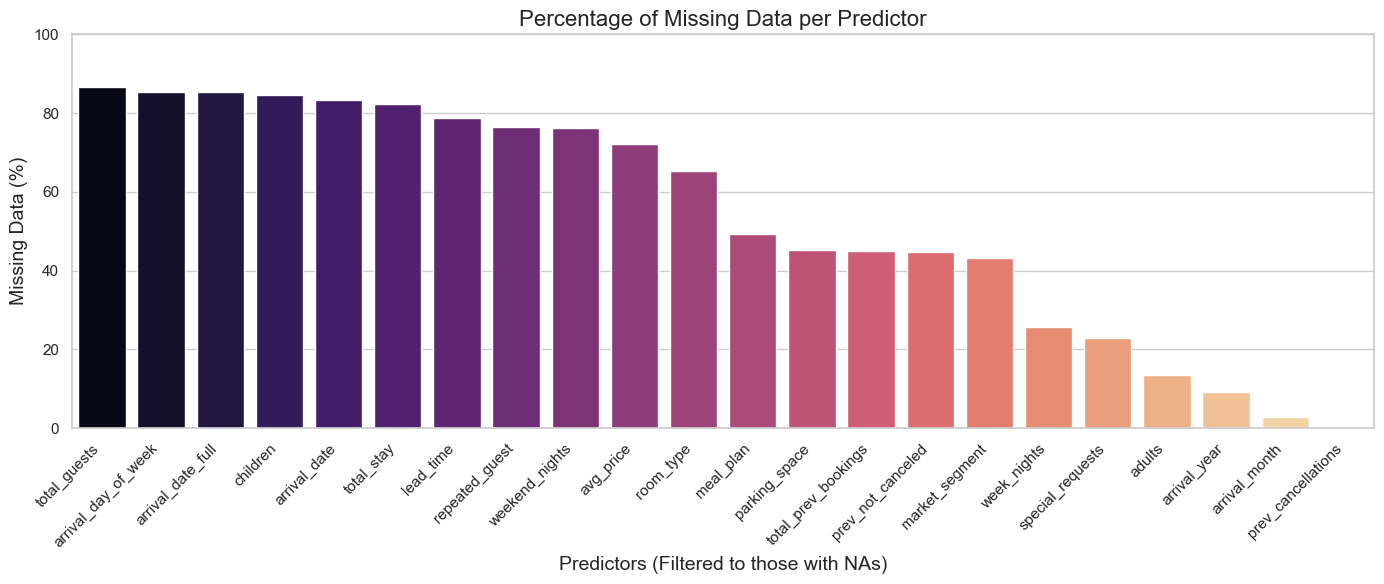

In [27]:
#### --- combination of previous 2 - percentage of missing per feature ----
#Calculate the percentage of missing values for each column
total_rows = len(data)
missing_percentage = (data.isnull().sum() / total_rows) * 100

# Filter out columns that have 0 missing values and sort descending
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if not missing_percentage.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette='magma')

    plt.title('Percentage of Missing Data per Predictor', fontsize=16)
    plt.xlabel('Predictors (Filtered to those with NAs)', fontsize=14)
    plt.ylabel('Missing Data (%)', fontsize=14)

    plt.ylim(0, 100)

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("No missing data found in the dataset!")

In part of predictor definition we will decide base on this graph that there is no point in using total_guest_arrival_date_full and some others. These two mostly because we engineered them artificially which aggregated the number of NAs.


## Variable encoding and predictor definition

– encode categorical variables (ordinal, one-hot, or target encoding) and apply numerical transformations where appropriate


– assess predictor strength (correlation, mutual information, univariate importance) and select a compact, justified subset


Imputation: We used median imputation for numerical values because variables like lead_time and avg_price are heavily skewed (proven by our earlier histograms), making the mean unreliable. Categorical missing values were grouped into a "Missing" category to capture any informative missingness.

Numerical Transformation (Log): A log-transformation (log1p) was applied to lead_time specifically for linear models to correct its rightward skew, stabilizing the variance.

Encoding Decision: We intentionally created two feature spaces. An ordinal-encoded space for Tree-based algorithms without creating high-dimensional sparsity, and one-hot encoded space to satisfy the geometric assumptions of linear models.

At this point we prepare version for information plots. We would also like to have the option to try multiple modeling approaches, hence we do one type of transformation for regression models and one for tree-based models.
Technically speaking, we are doing median imputing (more robust) and standard scaling for the whole training dataset which is not the best, it should be combined into pipeline to prevent data leakage when doing k-fold cross validation. However, this way the design seems simpler and we didnt do piplines so much in practicals, we didnt you mean target encoding (that would be a greater problem) and in the end we dont even use the regression model where it would create the most problems.

In [33]:
# 1. Separate features (X) and target (y)
cols_to_drop = ['booking_status']
X = data.drop(columns=cols_to_drop, errors='ignore').copy()
y = data['booking_status'].copy()

# 2. Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# --- STEP 1: GLOBAL IMPUTATION WITH INDICATORS ---
# add_indicator=True adds a binary column for any numerical feature that had NaNs
num_imputer = SimpleImputer(strategy='median', add_indicator=True)
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing', add_indicator=False)

# Fit and transform numeric data
X_num_imputed = num_imputer.fit_transform(X[num_cols])
num_imputed_names = num_imputer.get_feature_names_out(num_cols)

# Transform categorical data
X_cat_imputed = cat_imputer.fit_transform(X[cat_cols])

# Rebuild the DataFrame
X_imputed = pd.DataFrame(X_num_imputed, columns=num_imputed_names, index=X.index)
X_imputed[cat_cols] = X_cat_imputed




# --- VERSION A: TREE-BASED MODELS - classical
X_trees = X_imputed.copy()

X_trees[cat_cols] = X_trees[cat_cols].astype(str)

ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_trees[cat_cols] = ordinal_enc.fit_transform(X_trees[cat_cols])
print(f"Tree-ready dataset shape: {X_trees.shape}")


# --- VERSION B: LINEAR MODELS
X_linear = X_imputed.copy()

X_linear[cat_cols] = X_linear[cat_cols].astype(str)
# 1. Log Transform
if 'lead_time' in X_linear.columns:
    X_linear['lead_time'] = np.log1p(X_linear['lead_time'])

# 2. One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = ohe.fit_transform(X_linear[cat_cols])
encoded_cat_names = ohe.get_feature_names_out(cat_cols)

# Combine the new binary columns and drop the old text columns
encoded_df = pd.DataFrame(encoded_cats, columns=encoded_cat_names, index=X_linear.index)
X_linear = pd.concat([X_linear.drop(columns=cat_cols), encoded_df], axis=1)

# 3. Standard Scaling
# We only scale the original continuous numerical columns
cols_to_scale = [col for col in num_cols if col in X_linear.columns]
scaler = StandardScaler()
X_linear[cols_to_scale] = scaler.fit_transform(X_linear[cols_to_scale])

print(f"Linear-ready dataset shape: {X_linear.shape}")



Tree-ready dataset shape: (32295, 37)
Linear-ready dataset shape: (32295, 57)


here not removing NAs for XGB - they provide valuable info
Classic tree models need the imputed values.

In [43]:
# 1. Separate features (X) and target (y)
cols_to_drop = ['booking_status']
X_XGB = data.drop(columns=cols_to_drop, errors='ignore').copy()
y = data['booking_status'].copy()

# 2. Convert categorical columns to pandas 'category' dtype
# XGBoost handles 'category' dtypes natively, without needing OrdinalEncoder
cat_cols = X_XGB.select_dtypes(include=['object', 'string']).columns.tolist()

for col in cat_cols:
    X_XGB[col] = X_XGB[col].astype('category')

print(f"XGBoost-ready dataset shape: {X_XGB.shape}")

XGBoost-ready dataset shape: (32295, 22)


In [29]:
X_XGB

,adults,children,weekend_nights,week_nights,meal_plan,parking_space,room_type,lead_time,arrival_year,arrival_month,arrival_date,market_segment,repeated_guest,prev_cancellations,prev_not_canceled,avg_price,special_requests,arrival_date_full,arrival_day_of_week,total_prev_bookings,total_guests,total_stay
Booking_ID,,,,,,,,,,,,,,,,,,,,,,
INN10204,NaN,NaN,NaN,2.0,Meal Plan 2,NaN,Room_Type 6,NaN,2018,9,<NA>,Online,0.0,0.0,NaN,NaN,1.0,NaT,<NA>,NaN,NaN,NaN
INN20020,NaN,NaN,NaN,2.0,Meal Plan 1,NaN,NaN,NaN,<NA>,12,<NA>,Online,0.0,0.0,0.0,NaN,NaN,NaT,<NA>,0.0,NaN,NaN
INN16435,1.0,NaN,NaN,2.0,NaN,0.0,Room_Type 1,NaN,2018,11,<NA>,NaN,0.0,0.0,NaN,NaN,1.0,NaT,<NA>,NaN,NaN,NaN
INN07143,3.0,NaN,NaN,3.0,NaN,NaN,NaN,100.0,2018,5,<NA>,Online,0.0,0.0,NaN,NaN,2.0,NaT,<NA>,NaN,NaN,NaN
INN20511,1.0,0.0,1.0,1.0,Meal Plan 1,0.0,NaN,NaN,2018,11,<NA>,NaN,0.0,0.0,0.0,150.0,NaN,NaT,<NA>,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INN16851,2.0,NaN,NaN,NaN,Meal Plan 1,NaN,NaN,43.0,2017,12,26,Offline,NaN,0.0,0.0,NaN,2.0,2017-12-26,1,0.0,NaN,NaN
INN06266,1.0,NaN,NaN,2.0,Meal Plan 2,0.0,Room_Type 1,102.0,2017,10,<NA>,Online,NaN,0.0,NaN,80.0,NaN,NaT,<NA>,NaN,NaN,NaN
INN11285,2.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2018,5,<NA>,Corporate,0.0,0.0,0.0,NaN,1.0,NaT,<NA>,0.0,NaN,NaN


In [1]:
X_trees

NameError: name 'X_trees' is not defined



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future

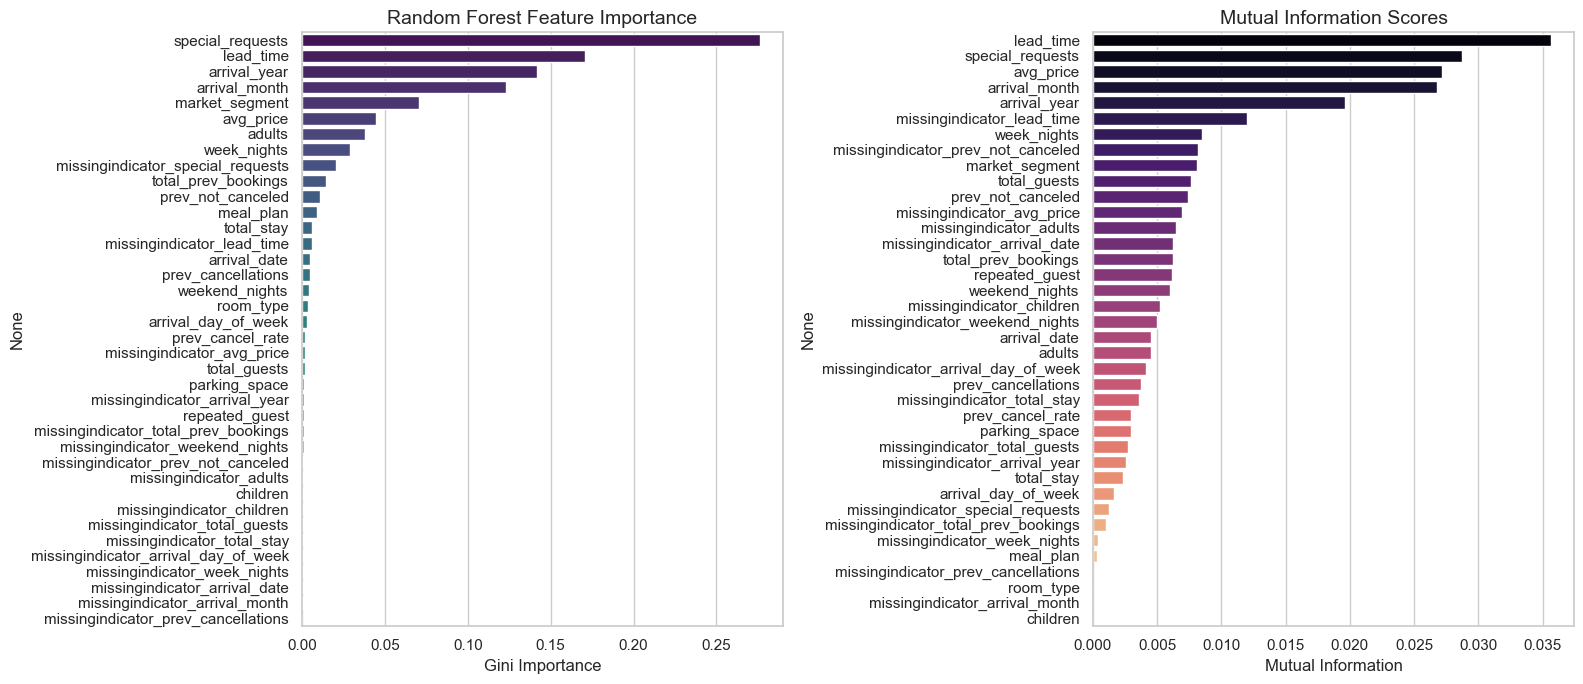

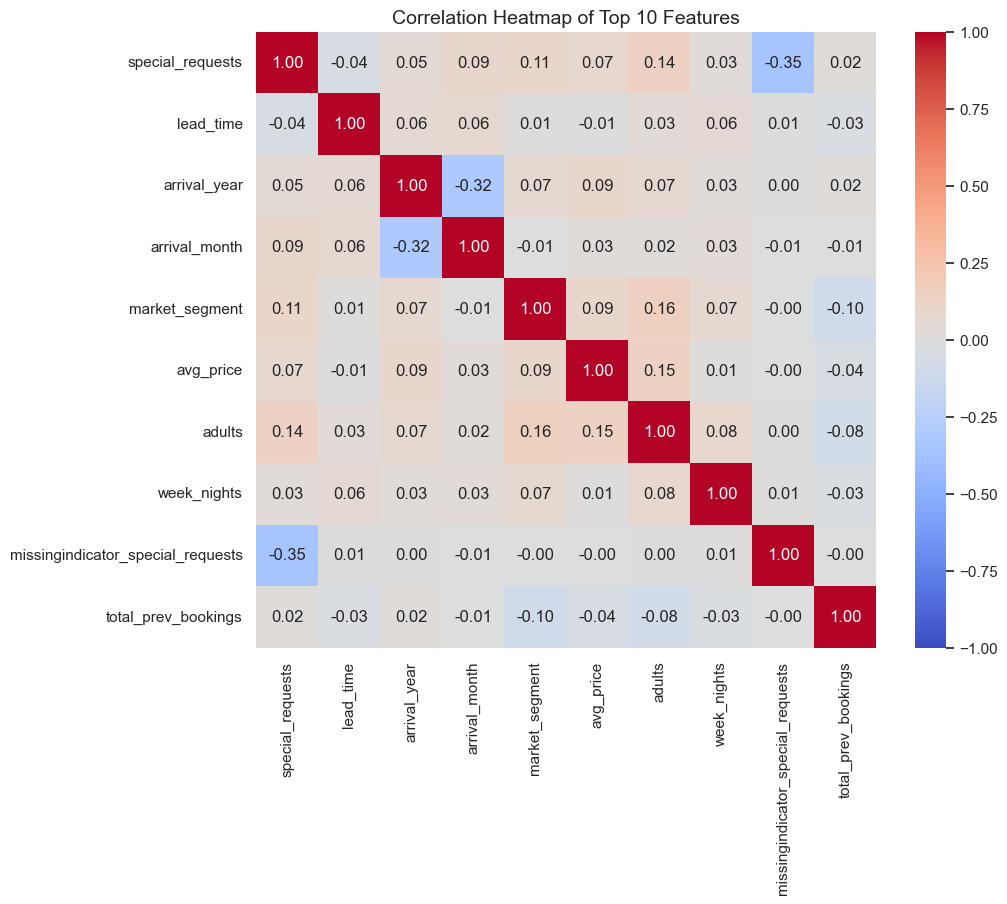

In [22]:
# --- 1. Random Forest - we start with a basic model just to assess general feature importance
# We limit max_depth so it doesn't overfit to noise
rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_trees, y)
rf_importance = pd.Series(rf.feature_importances_, index=X_trees.columns).sort_values(ascending=False)

# --- 2. Mutual Information (MI) ---
# MI measures the reduction in uncertainty for the target given a feature
mi_scores = mutual_info_classif(X_trees, y, random_state=42)
mi_importance = pd.Series(mi_scores, index=X_trees.columns).sort_values(ascending=False)

# --- 3. Plotting the Results ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot RF Importance
sns.barplot(x=rf_importance.values, y=rf_importance.index, ax=axes[0], palette='viridis')
axes[0].set_title('Random Forest Feature Importance', fontsize=14)
axes[0].set_xlabel('Gini Importance')

# Plot Mutual Information
sns.barplot(x=mi_importance.values, y=mi_importance.index, ax=axes[1], palette='magma')
axes[1].set_title('Mutual Information Scores', fontsize=14)
axes[1].set_xlabel('Mutual Information')

plt.tight_layout()
plt.show()

# --- 4. Redundancy Check (Correlation) ---
plt.figure(figsize=(10, 8))
# We select the top 10 features from the RF model to check for multicollinearity
top_10_features = rf_importance.head(10).index
corr_matrix = X_trees[top_10_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Top 10 Features', fontsize=14)
plt.show()


The correlation matrix of the top 10 features confirmed there is no significant multicollinearity, meaning all top features provide unique mathematical value to the model - however as mentioned before, we will get rid of some columns based on the full correlation matrix,


If we had to predict probabilities for future years we would have to drop arrival_year or treat it differently. As, however, our dataset (even the test one) is constrained only to year 2017,2018 and it has high predictive power, we will keep it a treat it as normal predictor.


All missingindicator_ columns: We added them to keep trakc of informative missingness, the charts proved that guests leaving fields blank was mostly random and didn't strongly predict cancellation. - the highest one was missing indicator for special requests. To simplify the model, we will get rid of all of those indicators.

- We should drop our engineered total_guests and total_stay columns and stick to the base columns (adults, children, week_nights, weekend_nights). The base columns contain the same information but preserve more non-null data.
- we should also drop arrival day of week as we saw on historgram it does not seem to help us predict and the cancel rate is distributed evenly and it also contains many NAs

In [31]:
final_predictors = [
    'special_requests',
    'lead_time',
    'arrival_year',
    'arrival_month',
    'avg_price',
    'market_segment',
    'adults',
    'week_nights',
    'weekend_nights',
    'total_prev_bookings',
    'prev_cancel_rate',
    'meal_plan',
    'repeated_guest',
    'parking_space'
]

## Models

We tried different models with various luck mentioned in the practicals classes. We trieed logistic regression, where we have most columns encoded. Then Random Forest and XGBoost. Best results were achieved with XGBoost and the final preditcitons are made using this model. We tried different hyperparameter optimization techniques - just to compare the results. For all mentioned we achieved the best results with Hyperopt.

Linear - logistic regresion

In [36]:
# --- 1. Tree Models ---
final_trees_cols = [
    'special_requests', 'lead_time', 'arrival_year', 'arrival_month',
    'avg_price', 'market_segment', 'adults', 'week_nights',
    'weekend_nights', 'total_prev_bookings',
    'meal_plan', 'repeated_guest', 'parking_space'
]
X_t = X_trees[final_trees_cols]
X_XGB_fin = X_XGB[final_trees_cols]

# --- 2. Linear Models ---
# continuous numerical columns
base_num_cols = [
    'special_requests', 'lead_time', 'avg_price', 'adults',
    'week_nights', 'weekend_nights', 'total_prev_bookings'
]

#list the categorical columns we want to include
cats_to_keep = [
    'market_segment', 'meal_plan', 'arrival_year',
    'arrival_month', 'repeated_guest', 'parking_space'
]

final_linear_cols = base_num_cols.copy()

# all their One-Hot Encoded variations without missing indicators
for cat in cats_to_keep:
    final_linear_cols += [
        col for col in X_linear.columns
        if col.startswith(f"{cat}_")
        and not col.endswith("_Missing")
        and not col.endswith("_nan")
    ]

# Slice the data
X_l = X_linear[final_linear_cols]

print(f"Tree Data Shape: {X_t.shape}")
print(f"Linear Data Shape: {X_l.shape}")



Tree Data Shape: (32295, 13)
Linear Data Shape: (32295, 20)


In [25]:
X_t

,special_requests,lead_time,arrival_year,arrival_month,avg_price,market_segment,adults,week_nights,weekend_nights,total_prev_bookings,prev_cancel_rate,meal_plan,repeated_guest,parking_space
Booking_ID,,,,,,,,,,,,,,
INN10204,1.0,59.0,2018.0,9.0,100.0,5.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,2.0
INN20020,0.0,59.0,2018.0,12.0,100.0,5.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0
INN16435,1.0,59.0,2018.0,11.0,100.0,3.0,1.0,2.0,1.0,0.0,0.0,3.0,0.0,0.0
INN07143,2.0,100.0,2018.0,5.0,100.0,5.0,3.0,3.0,1.0,0.0,0.0,3.0,0.0,2.0
INN20511,0.0,59.0,2018.0,11.0,150.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INN16851,2.0,43.0,2017.0,12.0,100.0,4.0,2.0,2.0,1.0,0.0,0.0,0.0,2.0,2.0
INN06266,0.0,102.0,2017.0,10.0,80.0,5.0,1.0,2.0,1.0,0.0,0.0,1.0,2.0,0.0
INN11285,1.0,59.0,2018.0,5.0,100.0,2.0,2.0,2.0,1.0,0.0,0.0,3.0,0.0,2.0


## Logistic regression with GridSearchCV and Hyperopt


For the Logistic Regression baseline, we used GridSearchCV to optimize the regularization parameters to maximize AUC. We tested different strengths of the inverse regularization parameter (C) alongside both l1 and l2 penalties using the liblinear solver.

We also employed Hyperopt (which is more general) to better compare results for all methods.

In [26]:
# Split the data (80% Training, 20% Testing)
# stratify=y - the 20% test set has the same ratio of cancellations as the full dataset
X_train_l, X_test_l, y_train, y_test = train_test_split(
    X_l, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
X_train_l

,special_requests,lead_time,avg_price,adults,week_nights,weekend_nights,total_prev_bookings,prev_cancel_rate,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Offline,market_segment_Online,meal_plan_Meal Plan 1,meal_plan_Meal Plan 2,meal_plan_Meal Plan 3,meal_plan_Not Selected,repeated_guest_0.0,repeated_guest_1.0,parking_space_0.0,parking_space_1.0
Booking_ID,,,,,,,,,,,,,,,,,,,,,
INN21945,-0.652287,0.104728,-0.052852,0.27717,-0.124444,0.105017,-0.069105,-0.05553,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
INN25647,-0.652287,0.104728,-1.540613,0.27717,-0.124444,0.105017,-0.069105,-0.05553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
INN01251,0.704246,0.104728,0.422591,-1.79104,0.695239,0.105017,-0.069105,-0.05553,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
INN05970,0.704246,-2.234174,-0.052852,-1.79104,1.514922,2.412176,-0.069105,-0.05553,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
INN22666,2.060779,0.104728,-0.052852,0.27717,-0.944126,-2.202142,-0.069105,-0.05553,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INN34115,-0.652287,0.104728,-0.052852,0.27717,-0.124444,0.105017,-0.069105,-0.05553,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
INN33216,-0.652287,0.104728,-0.052852,0.27717,-0.944126,0.105017,-0.069105,-0.05553,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
INN08893,0.704246,0.104728,3.595770,2.34538,-0.124444,0.105017,-0.069105,-0.05553,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# parameter grid
# testing different strengths of C, and both types of penalties
log_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # Required solver to use 'l1' penalty
}

# base model
# class_weight='balanced' to handle the cancellation imbalance
log_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#GridSearchCV
#5-fold cross-validation for every single combination
log_grid_search = GridSearchCV(
    estimator=log_base,
    param_grid=log_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)


log_grid_search.fit(X_train_l, y_train)

# Extract the Best Model and evaluate it
best_log = log_grid_search.best_estimator_

print(f"Best Parameters Found: {log_grid_search.best_params_}")

y_pred_proba_log = best_log.predict_proba(X_test_l)[:, 1]
optimized_log_auc = roc_auc_score(y_test, y_pred_proba_log)
print(f"Optimized Logistic Regression ROC AUC: {optimized_log_auc:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters Found: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Optimized Logistic Regression ROC AUC: 0.7168


In [29]:
#Hyperopt Search Space
log_space = {
    'C': hp.loguniform('C', np.log(0.001), np.log(100.0)),
    'penalty': hp.choice('penalty', ['l1', 'l2'])
}

#Objective Function
def log_objective(params):
    model = LogisticRegression(
        C=params['C'],
        penalty=params['penalty'],
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

    scores = cross_val_score(model, X_train_l, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    # Hyperopt minimizes, return the negative mean AUC
    return {'loss': -scores.mean(), 'status': STATUS_OK}

log_trials = Trials()

best_log_hyperopt = fmin(
    fn=log_objective,
    space=log_space,
    algo=tpe.suggest,
    max_evals=100,
    trials=log_trials,
    rstate=np.random.default_rng(42)
)

# Map the 'penalty' index back to the string
penalty_choices = ['l1', 'l2']
best_penalty = penalty_choices[best_log_hyperopt['penalty']]
best_C = best_log_hyperopt['C']

print("Best Parameters Found:")
print(f"    C: {best_C}")
print(f"    penalty: {best_penalty}")


final_log_model = LogisticRegression(
    C=best_C,
    penalty=best_penalty,
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

final_log_model.fit(X_train_l, y_train)

y_pred_proba_hyperopt_log = final_log_model.predict_proba(X_test_l)[:, 1]
final_hyperopt_log_auc = roc_auc_score(y_test, y_pred_proba_hyperopt_log)

print(f"\nFinal Test Set ROC AUC (Hyperopt LogReg): {final_hyperopt_log_auc:.4f}")

100%|██████████| 100/100 [00:47<00:00,  2.12trial/s, best loss: -0.7180888829042555]
Best Parameters Found:
    C: 0.19916195441508386
    penalty: l1

Final Test Set ROC AUC (Hyperopt LogReg): 0.7167


Parameter choice...
penalty: 'l1' vs 'l2'
    L1 Penalty If L1 decides a column isn't very useful, it will crush that feature's weight to exactly 0.00, completely deleting weak columns
    L2 Penalty - L2 will shrink the weights of weak columns so they don't dominate the model, but it almost never pushes them completely to zero.


Regularization Strength (C) - C stands for Inverse Regularization Strength - prevents overfitting
Small C (e.g., 0.001): High penalty. The model is highly restricted and forced to be extremely simple. (Risk: Underfitting).
Large C (e.g., 100): Low penalty. The model is allowed to trust the training data completely and assign massive weights to columns. (Risk: Overfitting).
we search C on a Logarithmic scale -changes in C only affect the math if you move by orders of magnitude.


Here for cross validation 5 instead of 3 - tree models are computationally heavy, 3 folds saves time. Linear models are  fast. Because Logistic Regression computes in seconds, we can afford to bump the cross-validation to 5 folds (cv=5)



Standard Classification Metrics:
                  precision    recall  f1-score   support

Not Canceled (0)       0.81      0.60      0.69      4355
    Canceled (1)       0.46      0.70      0.55      2104

        accuracy                           0.63      6459
       macro avg       0.63      0.65      0.62      6459
    weighted avg       0.69      0.63      0.64      6459



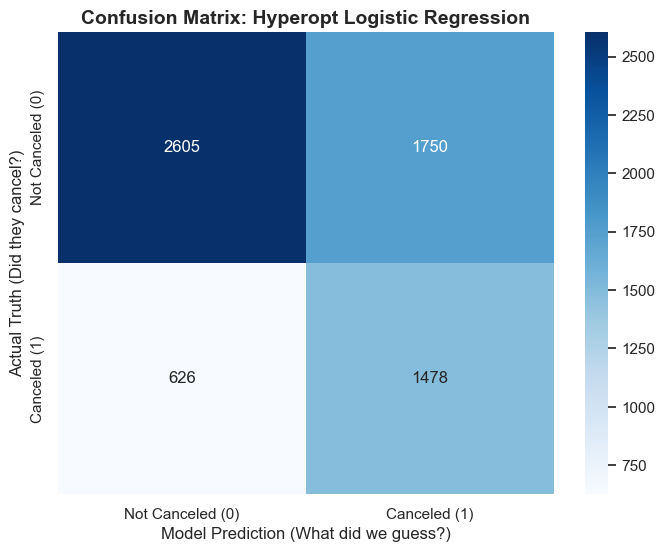

In [30]:
#standard 0.5 t-hold
y_pred_hyperopt_log = (y_pred_proba_hyperopt_log >= 0.5).astype(int)

# raw confusion matrix
cm = confusion_matrix(y_test, y_pred_hyperopt_log)

report = classification_report(
    y_test,
    y_pred_hyperopt_log,
    target_names=['Not Canceled (0)', 'Canceled (1)']
)

print("Standard Classification Metrics:")
print(report)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Canceled (0)', 'Canceled (1)'],
            yticklabels=['Not Canceled (0)', 'Canceled (1)'])

plt.title('Confusion Matrix: Hyperopt Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual Truth (Did they cancel?)', fontsize=12)
plt.xlabel('Model Prediction (What did we guess?)', fontsize=12)
plt.show()

Hyperopt is efficient for complex models like XGBoost, our experiment showed that Exhaustive Grid Search beat it for Logistic Regression. Both similar parameters estimated. Both successfully identified the L1 penalty, which seems to be the good solution in this case as we have many one-hot encoded columns

For the final hyperopt solution we have many false negatives but mainly extremely many false postivies (meaning falsely predicted canceled)

## Random Forest with RadomizedSearchCV, Hyperopt

In [31]:
# split the tree-ready data (80% Training, 20% Testing)
X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_t, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
X_train_t

,special_requests,lead_time,arrival_year,arrival_month,avg_price,market_segment,adults,week_nights,weekend_nights,total_prev_bookings,prev_cancel_rate,meal_plan,repeated_guest,parking_space
Booking_ID,,,,,,,,,,,,,,
INN21945,0.0,59.0,2018.0,9.0,100.00,4.0,2.0,2.0,1.0,0.0,0.0,0.0,2.0,2.0
INN25647,0.0,59.0,2018.0,5.0,72.15,3.0,2.0,2.0,1.0,0.0,0.0,3.0,2.0,0.0
INN01251,1.0,59.0,2018.0,7.0,108.90,5.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0
INN05970,1.0,11.0,2018.0,11.0,100.00,5.0,1.0,4.0,2.0,0.0,0.0,0.0,0.0,2.0
INN22666,2.0,59.0,2018.0,8.0,100.00,5.0,2.0,1.0,0.0,0.0,0.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INN34115,0.0,59.0,2018.0,8.0,100.00,4.0,2.0,2.0,1.0,0.0,0.0,1.0,2.0,0.0
INN33216,0.0,59.0,2018.0,11.0,100.00,3.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
INN08893,1.0,59.0,2018.0,8.0,168.30,5.0,3.0,2.0,1.0,0.0,0.0,3.0,2.0,2.0


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters Found: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 20}

--- Optimized Random Forest Performance ---

ROC AUC Score: 0.8005

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.71      0.77      4355
         1.0       0.55      0.74      0.63      2104

    accuracy                           0.72      6459
   macro avg       0.70      0.73      0.70      6459
weighted avg       0.75      0.72      0.73      6459



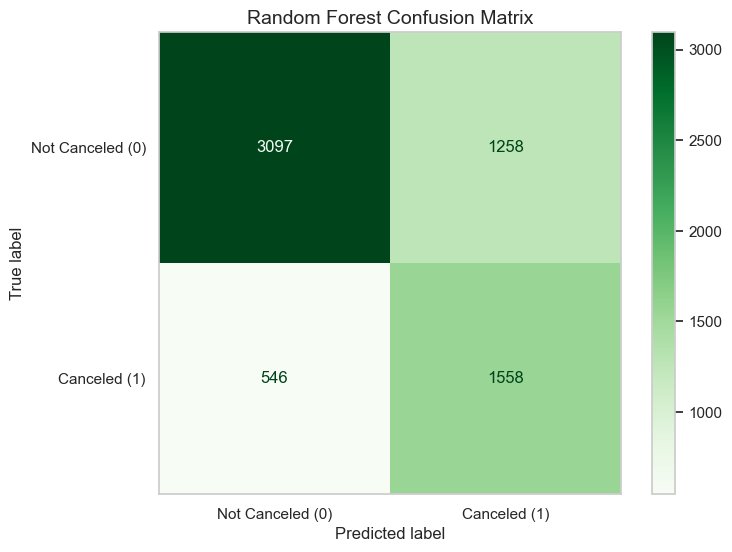

In [33]:
#Hyperparameter Grid
rf_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# base model
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

#Randomized Search #20 tests
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random_search.fit(X_train_t, y_train)

best_rf = rf_random_search.best_estimator_

print(f"Best Parameters Found: {rf_random_search.best_params_}\n")

y_pred_class_rf = best_rf.predict(X_test_t)
y_pred_proba_rf = best_rf.predict_proba(X_test_t)[:, 1]

# --- Evaluate Metrics ---
print("--- Optimized Random Forest Performance ---\n")

# Calculate ROC AUC
rf_auc_score = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC AUC Score: {rf_auc_score:.4f}\n")


print("Classification Report:")
print(classification_report(y_test, y_pred_class_rf))

cm = confusion_matrix(y_test, y_pred_class_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled (0)', 'Canceled (1)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Greens', ax=ax)
plt.title('Random Forest Confusion Matrix', fontsize=14)
plt.grid(False)
plt.show()

almost all metrics improved in comparison with Logistic Regresion, we mainly achived AUC of 0.8

In [34]:
#extended hyperparameter Grid
rf_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, None],
    'bootstrap': [True, False]
}


rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)


rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=30,               # I
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random_search.fit(X_train_t, y_train)


best_rf = rf_random_search.best_estimator_

print(f"Best Parameters Found: {rf_random_search.best_params_}\n")

y_pred_proba_rf = best_rf.predict_proba(X_test_t)[:, 1]
rf_auc_score = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Upgraded ROC AUC Score: {rf_auc_score:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters Found: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}

Upgraded ROC AUC Score: 0.8024


slightly better AUC score when adding option for max features and bootstrap

max_features: forcing some trees to only look at 50% (0.5) or the square root ('sqrt') of the columns,

bootstrap: Setting this to True means each tree gets a slightly randomized, shuffled version of the training data (sampling with replacement). Setting it to False means every tree sees the exact same training set.

Parameter choice...
(n_estimators) The total number of individual decision trees in "forest." - numbers [100, 200, 300, 400]: More trees generally equal better, more stable predictions, but only up to a certain point. After about 300-400 trees, performance usually doesnt get better


max_depth, min_samples_split, min_samples_leaf) -  parameters regularization
    max_depth [10, 15, 20, 25, None]: How many layers deep the tree is allowed to grow.
    Limiting depth to 10 or 15 forces the model to learn broad, general rules
    min_samples_split [2, 5, 10]: The minimum number of guests that must be in a group before the tree is allowed to split it again.
    min_samples_leaf [1, 2, 4]: absolute minimum number of guests allowed to be in a final "decision bucket" at the very bottom of the tree.
     preventing crazy predictions based on a single weird data point.


max_features, bootstrap - we want trees are different from each other. If all 400 trees are identical, the forest is useless.
    max_features ['sqrt', 'log2', 0.5, None]:  When a tree is trying to make a split, how many of 14 columns is it allowed to look at?
     'sqrt' means it's only allowed to look at ~3 or 4 random columns per split. This forces different trees to find hidden patterns in weaker columns.

bootstrap [True, False]: - Should the tree be trained on a random 80% subset of the rows (True), or the entire dataset (False)  - standard way is to choose true

In [35]:

#Hyperopt Search Space
rf_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 400, 10),
    'max_depth': hp.choice('max_depth', [10, 15, 20, 25, None]),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 4, 1),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', 0.5, None]),
    'bootstrap': hp.choice('bootstrap', [True, False])
}

# Objective Function
def rf_objective(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])

    # Instantiate the model with the current trial's parameters
    model = RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # 3-fold cross-validation
    scores = cross_val_score(model, X_train_t, y_train, cv=3, scoring='roc_auc', n_jobs=-1)

    return {'loss': -scores.mean(), 'status': STATUS_OK}

rf_trials = Trials()

best_rf_raw = fmin(
    fn=rf_objective,
    space=rf_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=rf_trials,
    rstate=np.random.default_rng(42)
)


best_rf_params = space_eval(rf_space, best_rf_raw)

best_rf_params['n_estimators'] = int(best_rf_params['n_estimators'])
best_rf_params['min_samples_split'] = int(best_rf_params['min_samples_split'])
best_rf_params['min_samples_leaf'] = int(best_rf_params['min_samples_leaf'])


print("Best Parameters Found:")
for key, value in best_rf_params.items():
    print(f"    {key}: {value}")


best_rf = RandomForestClassifier(
    **best_rf_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_t, y_train)

y_pred_proba_rf = best_rf.predict_proba(X_test_t)[:, 1]
rf_auc_score = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nUpgraded ROC AUC Score (Hyperopt): {rf_auc_score:.4f}")

100%|██████████| 30/30 [01:32<00:00,  3.07s/trial, best loss: -0.7989927008723652]
Best Parameters Found:
    bootstrap: True
    max_depth: 20
    max_features: 0.5
    min_samples_leaf: 3
    min_samples_split: 9
    n_estimators: 360

Upgraded ROC AUC Score (Hyperopt): 0.8035


by small margin hyperopt the best, it also chose Bootstrap to be True which is better for generalization. Connected with that we also have min_samples_split: 9 and min_samples_leaf: 3 compared to much smaller number with Randomized Search

Parameter choice...
hp.quniform('n_estimators', 100, 400, 10): Search anywhere between 100 and 400, but only return numbers in steps of 10 (100, 110, 120...)." The "q" stands for quantized. It treats this as a continuous mathematical landscape, meaning it knows that 110 is closely related to 120.

hp.choice('max_depth', [10, 15, None]): for categories or uneven lists. distinct options

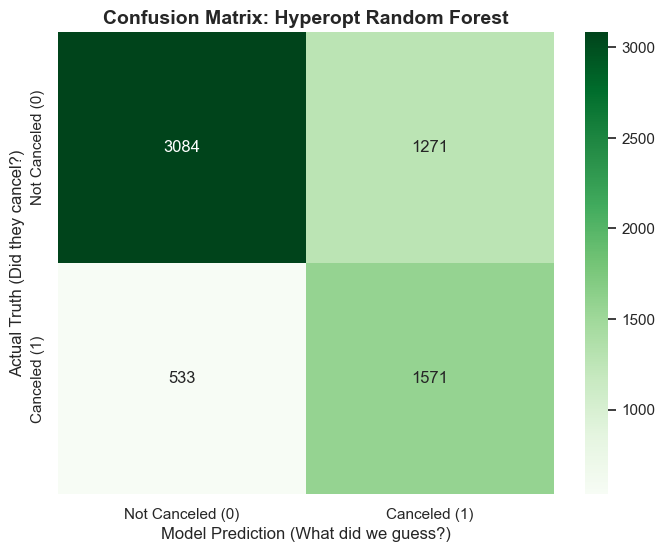


Standard Classification Metrics (Random Forest):
                  precision    recall  f1-score   support

Not Canceled (0)       0.85      0.71      0.77      4355
    Canceled (1)       0.55      0.75      0.64      2104

        accuracy                           0.72      6459
       macro avg       0.70      0.73      0.70      6459
    weighted avg       0.75      0.72      0.73      6459



In [36]:
# 0.5 threshold
y_pred_hyperopt_rf = (y_pred_proba_rf >= 0.5).astype(int)

cm_rf = confusion_matrix(y_test, y_pred_hyperopt_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Canceled (0)', 'Canceled (1)'],
            yticklabels=['Not Canceled (0)', 'Canceled (1)'])

plt.title('Confusion Matrix: Hyperopt Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual Truth (Did they cancel?)', fontsize=12)
plt.xlabel('Model Prediction (What did we guess?)', fontsize=12)
plt.show()

report_rf = classification_report(
    y_test,
    y_pred_hyperopt_rf,
    target_names=['Not Canceled (0)', 'Canceled (1)']
)

print("\nStandard Classification Metrics (Random Forest):")
print(report_rf)

## XGBOOST with Randomized Search and Hyperopt

corrected from before, XGBoost can process NAs

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters Found: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

--- Optimized XGBoost Performance ---

ROC AUC Score: 0.8208

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.71      0.77      4355
         1.0       0.56      0.76      0.64      2104

    accuracy                           0.72      6459
   macro avg       0.71      0.73      0.71      6459
weighted avg       0.76      0.72      0.73      6459



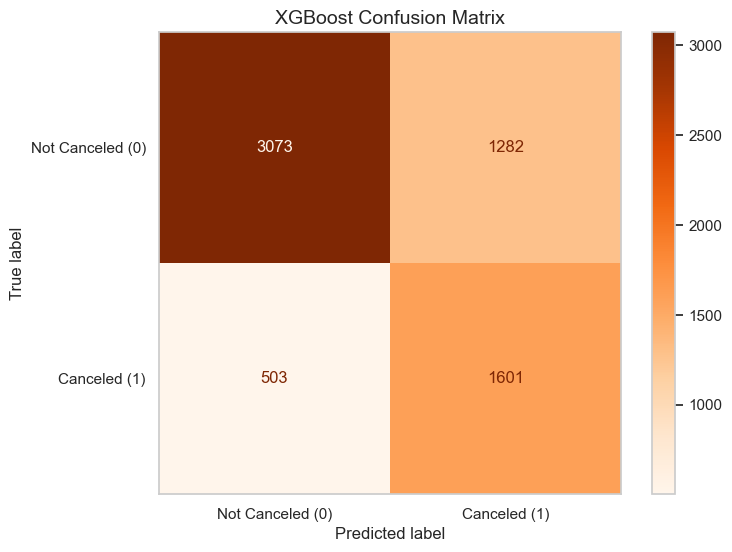

In [39]:

X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_XGB_fin, y, test_size=0.2, random_state=42, stratify=y
)

# class imbalance ratio for XGBoost
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

#Hyperparameter Grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],           #!
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

#base model
xgb_base = XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,  #Tells XGBoost to handle categories natively
    tree_method='hist'
)

#Randomized Search
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_random_search.fit(X_train_t, y_train)


best_xgb = xgb_random_search.best_estimator_

print(f"Best Parameters Found: {xgb_random_search.best_params_}\n")


y_pred_class_xgb = best_xgb.predict(X_test_t)
y_pred_proba_xgb = best_xgb.predict_proba(X_test_t)[:, 1]


print("--- Optimized XGBoost Performance ---\n")

# Calculate ROC AUC
xgb_auc_score = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC AUC Score: {xgb_auc_score:.4f}\n")


print("Classification Report:")
print(classification_report(y_test, y_pred_class_xgb))


cm = confusion_matrix(y_test, y_pred_class_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled (0)', 'Canceled (1)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Oranges', ax=ax)
plt.title('XGBoost Confusion Matrix', fontsize=14)
plt.grid(False)
plt.show()

Again slightly improved AUC, slightly more false positives but less false negatives compared to current best

100%|██████████| 30/30 [01:29<00:00,  2.99s/trial, best loss: -0.8172783157640223]
Best Parameters Found:
    colsample_bytree: 0.6905860093094504
    learning_rate: 0.02124414415269049
    max_depth: 10
    n_estimators: 370
    subsample: 0.8481131649056028


--- Optimized XGBoost Performance (Hyperopt) ---

ROC AUC Score: 0.8219

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.71      0.78      4355
         1.0       0.56      0.76      0.64      2104

    accuracy                           0.73      6459
   macro avg       0.71      0.73      0.71      6459
weighted avg       0.76      0.73      0.73      6459



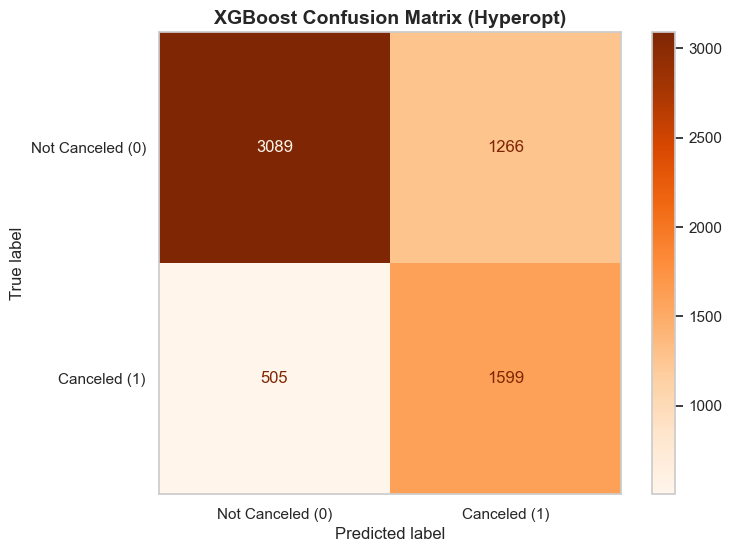

In [45]:
X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_XGB_fin, y, test_size=0.2, random_state=42, stratify=y
)
#imbalance ratio for XGBoost
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])


xgb_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 10),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
}


def xgb_objective(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])

    # Instantiate the base model with the trial parameters
    model = XGBClassifier(
        **params,
        scale_pos_weight=imbalance_ratio,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        enable_categorical=True,  #Tells XGBoost to handle categories natively
        tree_method='hist'
    )

    # 3-fold cross-validation
    scores = cross_val_score(model, X_train_t, y_train, cv=3, scoring='roc_auc', n_jobs=-1)

    return {'loss': -scores.mean(), 'status': STATUS_OK}

xgb_trials = Trials()

best_xgb_raw = fmin(
    fn=xgb_objective,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=xgb_trials,
    rstate=np.random.default_rng(42)
)

best_xgb_params = best_xgb_raw.copy()
best_xgb_params['n_estimators'] = int(best_xgb_params['n_estimators'])
best_xgb_params['max_depth'] = int(best_xgb_params['max_depth'])

print("Best Parameters Found:")
for key, value in best_xgb_params.items():
    print(f"    {key}: {value}")
print("\n")

#final model
best_xgb = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=imbalance_ratio,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,  #Tells XGBoost to handle categories natively
    tree_method='hist'
)

best_xgb.fit(X_train_t, y_train)

y_pred_class_xgb = best_xgb.predict(X_test_t)
y_pred_proba_xgb = best_xgb.predict_proba(X_test_t)[:, 1]

print("--- Optimized XGBoost Performance (Hyperopt) ---\n")

# Calculate ROC AUC
xgb_auc_score = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC AUC Score: {xgb_auc_score:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_class_xgb))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled (0)', 'Canceled (1)'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Oranges', ax=ax)
plt.title('XGBoost Confusion Matrix (Hyperopt)', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

the scores for both XGBoost models are similar, but hyperopt creates more generalized version that is much less likely to overfit.
Randomized Search: Picked subsample: 1.0. This means every single tree in the forest looked at 100% of the training rows - more likely to memorize
Hyperopt: Picked subsampl around 0.8 - more robust

also hyperopt slower learning rate, and other parameters

Parameter choice...

learning_rate & n_estimators - trees built one at a time, and each new tree is specifically designed to fix the mistakes of the previous tree.

n_estimators: How many trees are in the sequence.

learning_rate - How much we trust each new tree. A high learning rate means we let the new tree make massive corrections. A low learning rate means we force the tree to make tiny corrections.
     If we lower the learning_rate to make the model more cautious (e.g., 0.01), we must give it more trees (n_estimators: 500)

for hyperopt - (hp.loguniform): loguniform for the learning rate. the difference between a learning rate of 0.01 and 0.1 is massive (a 10x jump), while 0.1 to 0.2 is minor.

max_depth - How deep each individual tree is allowed to grow. Small compared to Random forest
    numbers [3, 5, 7, 10]: This is because Gradient Boosting relies on Weak Learners.

Stochastic Regularization - subsample & colsample_bytree
    subsample: What percentage of the guest rows does each tree get to look at
    colsample_bytree: What percentage of the 14 columns does each tree get to look at
    [0.6, 0.8, 1.0]: 1.0 means use 100% of the data. Dropping it to 0.6 means every tree only sees 60% of it. This forces the algorithm to rely on different columns and different guests every step of the way

cale_pos_weight - Because cancellations (1) are rarer than arrivals (0), the model might naturally try to boost its accuracy by just guessing 0 all the time.

In [ ]:
#From all mentioned, we deem the best XGBoost with hyperopt hyperparameter optimization as it achieved the best AUC score and seems to be generalizing the best

I additionally attempted Optuna even though it was not in practicals as it works very nice with XGBoost

In [47]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# Optuna Objective Function
def xgb_optuna_objective(trial):
    # The ultimate expanded search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

        # Advanced Regularization
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 100.0, log=True),

        # Static Parameters
        'scale_pos_weight': imbalance_ratio,
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
        'enable_categorical': True,  # <-- MOVED HERE
        'tree_method': 'hist'        # <-- MOVED HERE
    }

    # Instantiate the model with ALL parameters, including the categorical flags
    model = XGBClassifier(**params)

    # 3-Fold Stratified CV
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Cleaned up cross_val_score (removed the XGBoost kwargs)
    scores = cross_val_score(model, X_train_t, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    return scores.mean()
# 2. Create and Run the Study
# HIGHEST score
study = optuna.create_study(direction='maximize', study_name="XGBoost_Max_AUC")

# Run for 100 trials
study.optimize(xgb_optuna_objective, n_trials=100)

print(f"Best Validation AUC: {study.best_value:.4f}")
print("Best Parameters:")
best_optuna_params = study.best_params
for key, value in best_optuna_params.items():
    print(f"    {key}: {value}")

# Train the Final
best_xgb_optuna = XGBClassifier(
    **best_optuna_params,
    scale_pos_weight=imbalance_ratio,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,  #Tells XGBoost to handle categories natively
    tree_method='hist'
)

print("\nFitting final model on full training data...")
best_xgb_optuna.fit(X_train_t, y_train)

#Local Hold-Out Test Set
y_pred_proba_optuna = best_xgb_optuna.predict_proba(X_test_t)[:, 1]
optuna_auc_score = roc_auc_score(y_test, y_pred_proba_optuna)

print(f"\n--- Final Hold-Out ROC AUC Score: {optuna_auc_score:.4f} ---")

[I 2026-04-19 12:53:21,865] A new study created in memory with name: XGBoost_Max_AUC
[I 2026-04-19 12:53:30,773] Trial 0 finished with value: 0.8104710543160767 and parameters: {'n_estimators': 1870, 'learning_rate': 0.0375887839190061, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.8616223870271495, 'colsample_bytree': 0.882344344474768, 'gamma': 0.9387347019098397, 'reg_alpha': 4.18452773585894e-05, 'reg_lambda': 0.4629052226204796}. Best is trial 0 with value: 0.8104710543160767.
[I 2026-04-19 12:53:34,706] Trial 1 finished with value: 0.7843158166598672 and parameters: {'n_estimators': 1455, 'learning_rate': 0.03741487342202409, 'max_depth': 9, 'min_child_weight': 13, 'subsample': 0.6875174339785988, 'colsample_bytree': 0.8381117964604065, 'gamma': 1.5108859922501368, 'reg_alpha': 70.10725232336425, 'reg_lambda': 0.036159459793650955}. Best is trial 0 with value: 0.8104710543160767.
[I 2026-04-19 12:53:38,972] Trial 2 finished with value: 0.8021083392918076 and parameters: {

Best Validation AUC: 0.8189
Best Parameters:
    n_estimators: 1637
    learning_rate: 0.009325911791966
    max_depth: 12
    min_child_weight: 1
    subsample: 0.7892034607427573
    colsample_bytree: 0.6283671003189963
    gamma: 3.057625133462372
    reg_alpha: 0.000740961635740192
    reg_lambda: 0.00607305033483109

Fitting final model on full training data...

--- Final Hold-Out ROC AUC Score: 0.8232 ---


## Final model graphs



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future

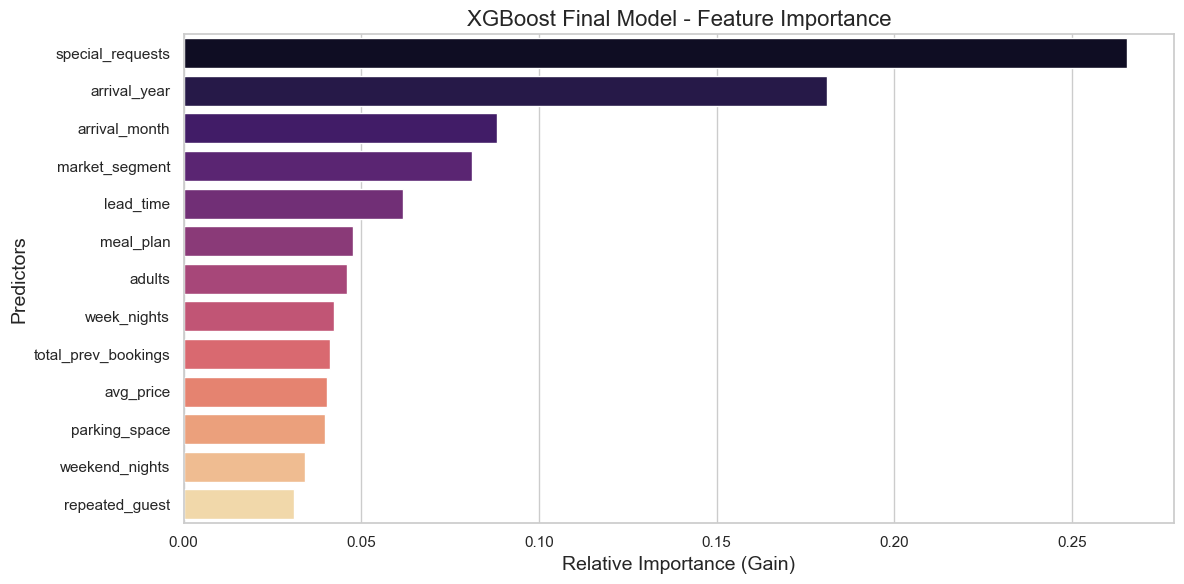

In [48]:
#importance scores and feature names
importances = best_xgb_optuna.feature_importances_
feature_names = X_train_t.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('XGBoost Final Model - Feature Importance', fontsize=16)
plt.xlabel('Relative Importance (Gain)', fontsize=14)
plt.ylabel('Predictors', fontsize=14)
plt.tight_layout()
plt.show()

in accordance with initial graphs, the most important features are year, number of special requests, matket segment, time leading to reservation


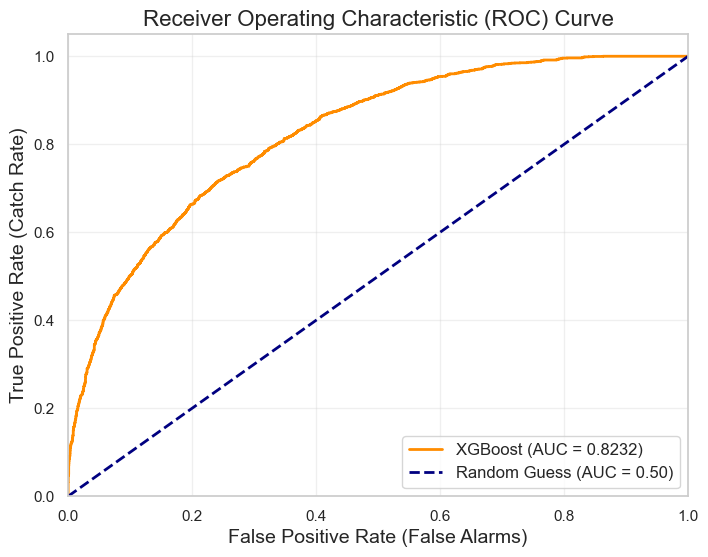

In [49]:

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_optuna)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
#50/50 random guess line for comparison
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)', fontsize=14)
plt.ylabel('True Positive Rate (Catch Rate)', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

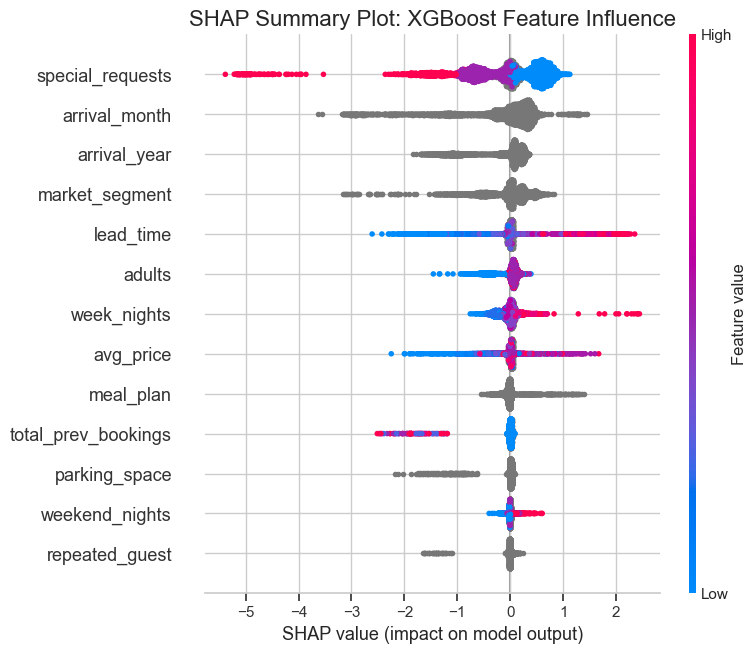

In [50]:
#SHAP for train test split test (we dont have labels for actual test set)
# SHAP explainer with best XGBoost model
# TreeExplainer is highly optimized for models like XGBoost and Random Forest
explainer = shap.TreeExplainer(best_xgb_optuna)

# 2. Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(X_test_t)

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 8))
# The summary plot automatically handles the rendering
shap.summary_plot(shap_values, X_test_t, show=False)

plt.title('SHAP Summary Plot: XGBoost Feature Influence', fontsize=16)
plt.tight_layout()
plt.show()

Features are ranked from top to bottom by importance. special_requests is the #1 most important driver of model.

We specifically formatted features like market_segment, meal_plan, and parking_space as pandas category types so XGBoost could handle them natively. The SHAP plotting library recognizes this and the interpretation of incresing/decreasing category doesnt hold here


When guests make multiple special requests (pink), their risk of cancellation drops. This makes  sense: guests who take the time to ask for a specila request are invested in their trip. Conversely, the blue dots (0 requests) cluster slightly to the right, meaning guests who ask for nothing are slightly more likely to cancel.

Guests who book their rooms far in advance (High lead time = pink) are significantly more likely to cancel. When people book 6 months out many things can happen in that time fraem. Blue dots (booking at the last minute) are on the left, meaning last-minute bookers almost always show up.


avg_price:streak of pink dots pushing to the right. More expensive rooms a slightly higher risk of cancellation

The Low-Risk Guest that is likely to arrive would be a loyal repeat customer who books at the last minute, asks for a parking space, and makes several special requests for their room.

The High-Risk Guest who is likely to cnacel might be a first-time guest who books an expensive room many months in advance and makes absolutely zero special requests.

## Test prediction

"I intially thought we were supposed to predict 0/1 so I tried to optimize the treshold for deciding, but then I realized we should keep the probabilities but I still liked the picture so I kept it here."

--- Optimal Probability Threshold --
Default 0.5 Threshold F1-Score: 0.6400
Optimal Threshold Found:        0.5393
Maximum Validation F1-Score:    0.6466
Total F1-Score Improvement:     +0.0067


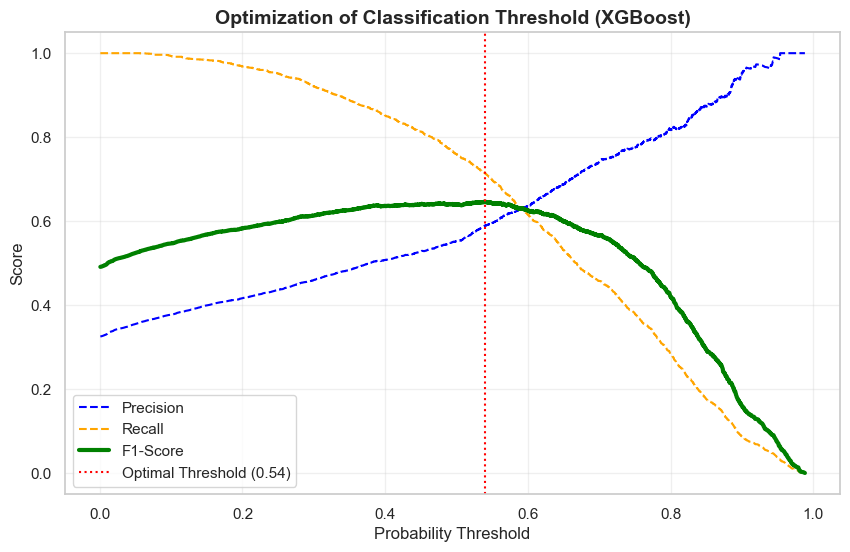

In [51]:

print("--- Optimal Probability Threshold --")

# probabilities form local test set (the 20%)
local_probs = best_xgb_optuna.predict_proba(X_test_t)[:, 1]

#Precision, Recall, and all possible Thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, local_probs)

#F1-Score for every single threshold mathematically
# 1e-10 prevents division by zero error
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)


optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
max_f1 = f1_scores[optimal_idx]

# what if we chose 0.5?
# Find the threshold closest to 0.5
default_idx = np.argmin(np.abs(thresholds - 0.5))
default_f1 = f1_scores[default_idx]

print(f"Default 0.5 Threshold F1-Score: {default_f1:.4f}")
print(f"Optimal Threshold Found:        {optimal_threshold:.4f}")
print(f"Maximum Validation F1-Score:    {max_f1:.4f}")
print(f"Total F1-Score Improvement:     +{max_f1 - default_f1:.4f}")


plt.figure(figsize=(10, 6))

# Plot the three lines
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue', linestyle='--')
plt.plot(thresholds, recalls[:-1], label='Recall', color='orange', linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=3)

# Mark optimal point
plt.axvline(x=optimal_threshold, color='red', linestyle=':',
            label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.title('Optimization of Classification Threshold (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
optimal_threshold

0.5457599

In [62]:
#load blind test data
blind_test = pd.read_csv('Data/2025_DS2_HW1_data_test.csv')

#Rename columns exactly as in training
rename_dict = {
    'no_of_adults': 'adults',
    'no_of_children': 'children',
    'no_of_weekend_nights': 'weekend_nights',
    'no_of_week_nights': 'week_nights',
    'type_of_meal_plan': 'meal_plan',
    'required_car_parking_space': 'parking_space',
    'room_type_reserved': 'room_type',
    'market_segment_type': 'market_segment',
    'repeated_guest': 'repeated_guest',
    'no_of_previous_cancellations': 'prev_cancellations',
    'no_of_previous_bookings_not_canceled': 'prev_not_canceled',
    'avg_price_per_room': 'avg_price',
    'no_of_special_requests': 'special_requests'
}
blind_test = blind_test.rename(columns=rename_dict)

#Feature engineering replication
# Dates
year_str = pd.to_numeric(blind_test['arrival_year'], errors='coerce').fillna(-1).astype(int).astype(str)
month_str = pd.to_numeric(blind_test['arrival_month'], errors='coerce').fillna(-1).astype(int).astype(str)
day_str = pd.to_numeric(blind_test['arrival_date'], errors='coerce').fillna(-1).astype(int).astype(str)

blind_test['arrival_date_full'] = pd.to_datetime(
    year_str + '-' + month_str + '-' + day_str,
    format='%Y-%m-%d',
    errors='coerce'
)
blind_test['arrival_day_of_week'] = blind_test['arrival_date_full'].dt.dayofweek

# Historical Rates (Updated to yield NaN instead of 0 for missing/new guests)
blind_test['total_prev_bookings'] = blind_test['prev_cancellations'] + blind_test['prev_not_canceled']
blind_test['prev_cancel_rate'] = (blind_test['prev_cancellations'] / blind_test['total_prev_bookings']).replace([np.inf, -np.inf], np.nan)

# Aggregates
blind_test['total_guests'] = blind_test['adults'] + blind_test['children']
blind_test['total_stay'] = blind_test['weekend_nights'] + blind_test['week_nights']


#Select Final Predictors
final_predictors = [
    'special_requests', 'lead_time', 'arrival_year', 'arrival_month',
    'avg_price', 'market_segment', 'adults', 'week_nights',
    'weekend_nights', 'total_prev_bookings',
    'meal_plan', 'repeated_guest', 'parking_space'
]

X_final = blind_test[final_predictors].copy()

#convert necessary columns to 'category' dtype

categorical_features = [
    'arrival_year', 'arrival_month', 'market_segment',
    'meal_plan', 'repeated_guest', 'parking_space'
]

for col in categorical_features:
    if col in X_final.columns:
        X_final[col] = X_final[col].astype(X_train_t[col].dtype) # to prevent data misalignment

#Predict using the Optuna-tuned model
print("Calculating probabilities using Optuna-tuned XGBoost...")
# Using best_xgb_optuna from your previous script
final_submission_probs = best_xgb_optuna.predict_proba(X_final)[:, 1]

#Export to CSV
submission_df_hard = pd.DataFrame({
    'Booking_ID': blind_test['Booking_ID'],
    'prediction': final_submission_probs
})

submission_df_hard.to_csv('final_xgboost_optuna_new_1_predictions.csv', index=False)

print(f"Exported {len(submission_df_hard)} predictions to 'final_xgboost_optuna_new_1_predictions.csv'.")

Calculating probabilities using Optuna-tuned XGBoost...
Exported 3593 predictions to 'final_xgboost_optuna_new_1_predictions.csv'.


In [61]:
blind_test

,Booking_ID,adults,children,weekend_nights,week_nights,meal_plan,parking_space,room_type,lead_time,arrival_year,arrival_month,arrival_date,market_segment,repeated_guest,prev_cancellations,prev_not_canceled,avg_price,special_requests,arrival_date_full,arrival_day_of_week,total_prev_bookings,prev_cancel_rate,total_guests,total_stay
0,INN04969,2.0,NaN,1.0,0.0,Meal Plan 1,NaN,NaN,NaN,2017.0,8.0,23.0,NaN,NaN,0.0,NaN,NaN,3.0,2017-08-23,2.0,NaN,NaN,NaN,1.0
1,INN34541,2.0,0.0,NaN,2.0,Meal Plan 1,0.0,NaN,NaN,2018.0,2.0,NaN,Offline,NaN,0.0,0.0,NaN,NaN,NaT,NaN,0.0,NaN,2.0,NaN
2,INN36109,2.0,NaN,NaN,2.0,Meal Plan 1,0.0,NaN,NaN,2018.0,12.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
3,INN01554,2.0,NaN,0.0,3.0,NaN,0.0,NaN,NaN,2018.0,6.0,21.0,Online,NaN,0.0,0.0,NaN,0.0,2018-06-21,3.0,0.0,NaN,NaN,3.0
4,INN24975,2.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,2018.0,9.0,NaN,NaN,NaN,0.0,NaN,NaN,2.0,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3588,INN29523,1.0,NaN,NaN,2.0,Meal Plan 2,0.0,Room_Type 1,39.0,2017.0,8.0,NaN,Offline,NaN,0.0,NaN,87.00,NaN,NaT,NaN,NaN,NaN,NaN,NaN
3589,INN25061,2.0,NaN,1.0,NaN,Not Selected,0.0,NaN,NaN,2018.0,6.0,NaN,Online,0.0,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
3590,INN08475,2.0,NaN,NaN,NaN,NaN,NaN,NaN,308.0,2018.0,11.0,NaN,Online,NaN,0.0,0.0,78.30,NaN,NaT,NaN,0.0,NaN,NaN,NaN
3591,INN13558,1.0,NaN,NaN,0.0,Meal Plan 1,NaN,NaN,NaN,2018.0,7.0,24.0,NaN,NaN,3.0,39.0,NaN,0.0,2018-07-24,1.0,42.0,0.071429,NaN,NaN


## Useless

Generating final probabilities using Optuna Champion...
Success! Exported 3593 probability predictions to 'final_xgboost_optuna_probabilities.csv'.


In [ ]:
## Hyperopt


## hyperopt
